## EDA pentru dataset-ul hybrid.

In [ ]:
# Facem importurile necesare
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Incarcam datele
df = pd.read_csv('mental_health_workplace_survey.csv')

# Verificam primele randuri
df.head()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
0,1001,50,Male,UK,Sales Associate,HR,14,47,No,3.37,...,117,No,3.15,Yes,8,40K-60K,8.82,6,9.20,0
1,1002,36,Male,Germany,Software Engineer,IT,1,59,Hybrid,7.39,...,8,Yes,4.40,Yes,4,80K-100K,2.80,45,8.46,1
2,1003,29,Non-binary,India,IT Admin,IT,13,59,Hybrid,7.10,...,75,No,3.63,No,6,80K-100K,7.28,7,7.96,1
3,1004,42,Male,Australia,HR Specialist,IT,15,31,Yes,4.18,...,43,Yes,4.50,Yes,9,60K-80K,1.31,11,8.90,0
4,1005,40,Male,Brazil,Customer Support,Support,6,34,Yes,8.28,...,58,Yes,5.51,Yes,6,<40K,1.17,18,8.88,1


# Week 4 - Curatarea datelor

In [ ]:
# 1. Verificam daca avem duplicate, iar mai apoi le eliminam
duplicate_count = df.duplicated().sum()
print(f"Randuri duplicate gasite: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicatele au fost eliminate!")

# 2. Verificam daca avem valori lipsa
print("\nValori lipsa per coloana:")
missing_per_col = df.isnull().sum()
if missing_per_col.sum() > 0:
    print(missing_per_col[missing_per_col > 0])
else:
    print("Niciuna dintre coloane nu are valori lipsa!")

# 3. Eliminam randurile cu valori lipsa (daca este cazul)
missing_count = df.isnull().sum().sum()
if missing_count > 0:
    df = df.dropna()
    print(f"\nRandurile cu valori lipsa au fost eliminate!")

# 4. Eliminam coloanele care nu ajuta algoritmul
# 'EmployeeID' este doar un numar de ordine
if 'EmployeeID' in df.columns:
    df = df.drop(columns=['EmployeeID'])
    print("\nColoana 'EmployeeID' a fost eliminata.")

print(f"\nDatele sunt curate! Tabelul final are {df.shape[0]} randuri si {df.shape[1]} coloane.")

Randuri duplicate gasite: 0

Valori lipsa per coloana:
Niciuna dintre coloane nu are valori lipsa!

Coloana 'EmployeeID' a fost eliminata.

Datele sunt curate! Tabelul final are 3000 randuri si 24 coloane.


# EDA

C:\Users\marco\AppData\Local\Temp\ipykernel_16784\605936519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='BurnoutRisk', palette='viridis')


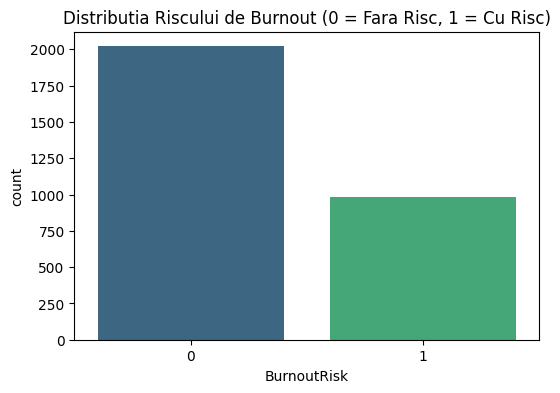

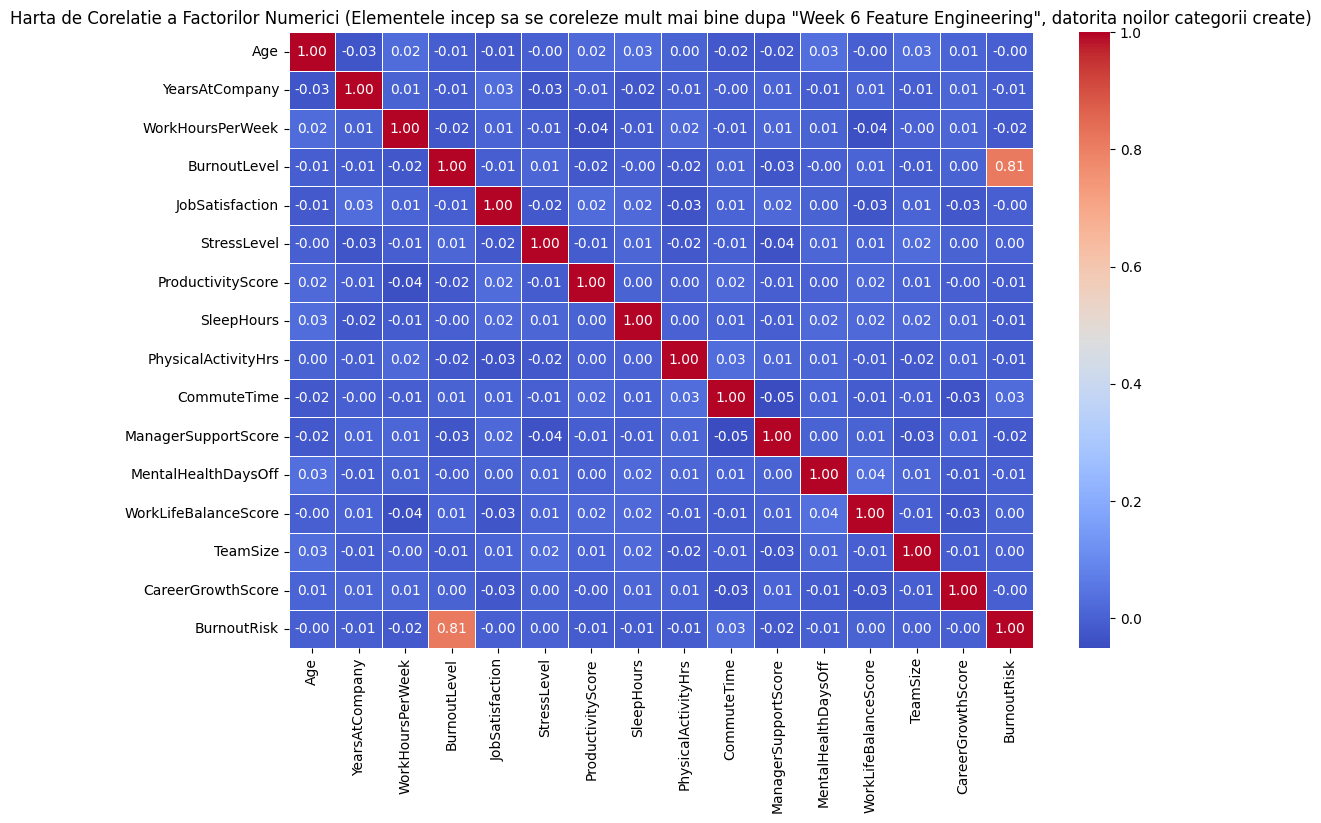

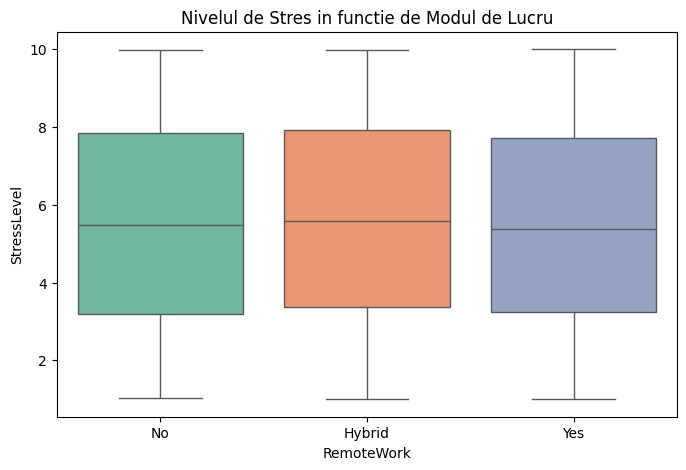

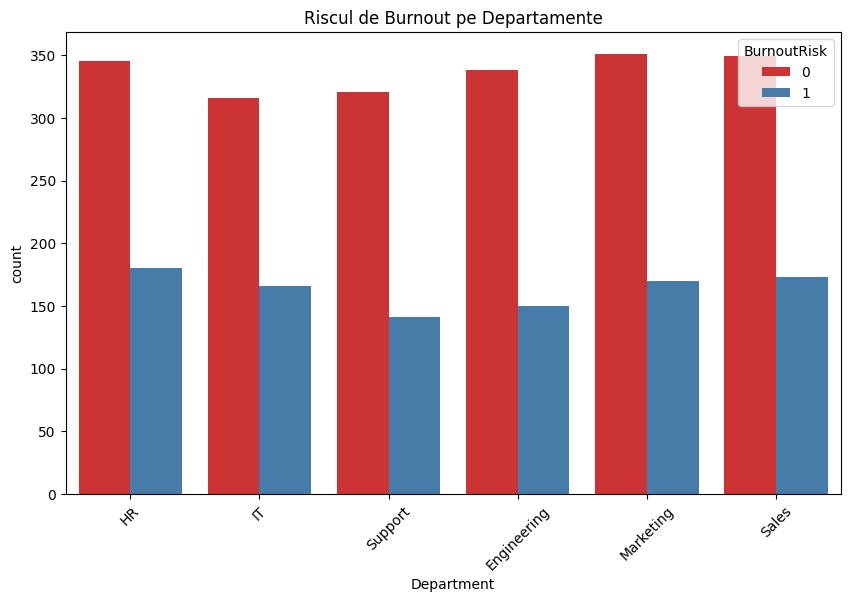

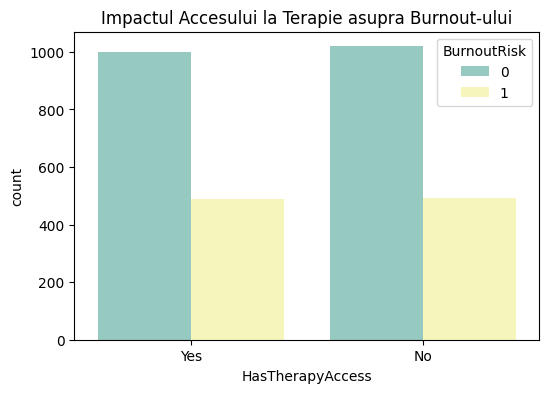

In [ ]:
# 1. Distribuim variabila de risc pentru burnout ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='BurnoutRisk', palette='viridis')
plt.title("Distributia Riscului de Burnout (0 = Fara Risc, 1 = Cu Risc)")
plt.show()

# 2. Harta de Corelatie
plt.figure(figsize=(12, 8))
# Selectam doar coloanele numerice pentru a evita erori
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Cream si afisam harta
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Harta de Corelatie a Factorilor Numerici (Elementele incep sa se coreleze mult mai bine dupa "Week 6 Feature Engineering", datorita noilor categorii create)')
plt.show()

# 3. Stresul vs. Munca Remote
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='RemoteWork', y='StressLevel', hue='RemoteWork', palette='Set2', legend=False)
plt.title('Nivelul de Stres in functie de Modul de Lucru')
plt.show()

# 4. Riscul de Burnout pe Departamente
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='BurnoutRisk', palette='Set1')
plt.title('Riscul de Burnout pe Departamente')
plt.xticks(rotation=45) # Rotim textul ca sa se citeasca usor
plt.show()

# 5. Riscul de Burnout in functie de Accesul la Terapie
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HasTherapyAccess', hue='BurnoutRisk', palette='Set3')
plt.title('Impactul Accesului la Terapie asupra Burnout-ului')
plt.show()

# Week 6 - Ingineria caracteristicilor

## Feature engineering (Noi categorii)

In [ ]:
# 1. Stress vs Support
df['StressSupportRatio'] = df['StressLevel'] / (df['ManagerSupportScore'] + 1)

# 2. Recovery Index
df['RecoveryIndex'] = df['SleepHours'] + df['PhysicalActivityHrs']

# 3. Work-Life Balance Index
df['WorkLifeBalanceIndex'] = df['WorkHoursPerWeek'] / (df['WorkLifeBalanceScore'] + 1)

# 4. Salary Rank (Ordinal Encoding)
salary_map = {'<40K': 1, '40K-60K': 2, '60K-80K': 3, '80K-100K': 4, '100K+': 5}
df['SalaryRank'] = df['SalaryRange'].map(salary_map)

# 5. Commute Stress Factor
df['CommuteStressFactor'] = df['CommuteTime'] * (10 - df['JobSatisfaction'])

# 6. Tenure Ratio
df['TenureRatio'] = df['YearsAtCompany'] / df['Age']

# Conversii preliminare pentru calcule
df['HasMentalHealthSupport_num'] = df['HasMentalHealthSupport'].map({'Yes': 1, 'No': 0})
df['HasTherapyAccess_num'] = df['HasTherapyAccess'].map({'Yes': 1, 'No': 0})

# 7. Mental Health Resilience (scor pentru rezilienta/rezistenta mentala)
df['MentalHealthResilience'] = (df['HasMentalHealthSupport_num'] + df['HasTherapyAccess_num'] + df['MentalHealthDaysOff']/10) * (df['SleepHours'] + df['PhysicalActivityHrs'])

# 8. Work-Life Extremity (scor pentru cat de dezechilibrat este stilul de viata)
df['WorkLifeExtremity'] = abs(df['WorkHoursPerWeek'] - 40) + abs(df['SleepHours'] - 8) + abs(df['PhysicalActivityHrs'] - 5)

# 9. Satisfaction-Stress Tension
df['SatisfactionStressTension'] = df['StressLevel'] * (10 - df['JobSatisfaction'])

# 10. Burnout Risk Multiplier
df['BurnoutRiskMultiplier'] = (df['StressLevel'] * df['WorkHoursPerWeek']) / ((df['ManagerSupportScore'] + 1) * (df['JobSatisfaction'] + 1))

# 11. Career vs Satisfaction
df['CareerVsSatisfaction'] = abs(df['CareerGrowthScore'] - df['JobSatisfaction'])

# 12. Wellness Index (0-100)
df['WellnessIndex'] = (
    (df['SleepHours'] / 8 * 20) +
    (df['PhysicalActivityHrs'] / 5 * 15) +
    (df['JobSatisfaction'] / 10 * 20) +
    (df['WorkLifeBalanceScore'] / 10 * 20) +
    (df['HasMentalHealthSupport_num'] * 15) +
    ((10 - df['StressLevel']) / 10 * 10)
)

# 13. Sleep Deficit
df['SleepDeficit'] = (8 - df['SleepHours']).clip(lower=0)

# 14. Satisfaction-Stress Gap
df['SatisfactionStressGap'] = df['JobSatisfaction'] / (df['StressLevel'] + 1)

# 15. Work-Recovery Ratio
df['WorkRecoveryRatio'] = df['WorkHoursPerWeek'] / (df['SleepHours'] + df['PhysicalActivityHrs'])

if 'X' not in locals():
    numeric_data = df.select_dtypes(include=[np.number])
    X = numeric_data.drop('BurnoutRisk', axis=1)

if 'BurnoutLevel' in X.columns:
    X = X.drop('BurnoutLevel', axis=1)
    print(f"   ✓ BurnoutLevel eliminat!")

   ✓ BurnoutLevel eliminat!


## 📊 Analiza Eliminării Features - Multicolinaritate și Redundanță | Ce am eliminat si de ce?

### ❌ 1. PersonalTimeScore vs RecoveryIndex

**Formula:**
- `PersonalTimeScore = SleepHours + PhysicalActivityHrs`
- `RecoveryIndex = SleepHours + PhysicalActivityHrs`

**De ce am eliminat PersonalTimeScore?**
- ✓ **Sunt IDENTICI** - exact aceeași formulă
- Multicolinaritate perfectă (corelație 1.0)
- Modelul vede informația de 2 ori = bias nerecesar
- `RecoveryIndex` e suficient

**Verdict:** Păstrează `RecoveryIndex` ✅

---

### ❌ 2. WorkSleepRatio vs WorkRecoveryRatio

**Formula:**
- `WorkSleepRatio = WorkHours / (SleepHours × 7)` ← Multiplicator artificial
- `WorkRecoveryRatio = WorkHours / (SleepHours + PhysicalActivityHrs)` ← Complet

**Exemplu numeric:**
```
Persoană: 50h munca, 6h somn, 3h sport

WorkSleepRatio = 50 / (6 × 7) = 50/42 = 1.19
WorkRecoveryRatio = 50 / (6 + 3) = 50/9 = 5.56
```

**De ce am eliminat WorkSleepRatio?**
- ❌ Multiplicatorul ×7 e **artificial și confuz** (de ce ×7 și nu ×1?)
- ❌ **Ignora sport complet** - două persoane cu capacități diferite par identice
- ✅ `WorkRecoveryRatio` include sport = **mai complet și util**
- ✅ `WorkRecoveryRatio` vede capacitate reală de recuperare

**Exemplu:**
```
Persoană A (stresată): 50h munca, 6h somn, 0h sport
WorkRecoveryRatio = 50/6 = 8.33 ⚠️ RISC MARE

Persoană B (activă): 50h munca, 6h somn, 5h sport
WorkRecoveryRatio = 50/11 = 4.55 ✅ Balanță mai bună

WorkSleepRatio: ambele = 1.19 → NU DIFERENȚIAZĂ!
```

**Verdict:** Elimină `WorkSleepRatio`, păstrează `WorkRecoveryRatio` ✅

---

### ❌ 3. StressManagementCapacity vs SatisfactionStressGap + ManagerSupportEfficiency

**Formula:**
- `StressManagementCapacity = (Support + Balance + Satisfaction) / (Stress + 1)`
- `SatisfactionStressGap = Satisfaction / (Stress + 1)` ← Simplu și direct
- `ManagerSupportEfficiency = (Support × Satisfaction) / (Stress + 1)` ← Granular

**De ce am eliminat StressManagementCapacity?**
- ❌ E o **medie complexă** a mai multor features (Support + Balance + Satisfaction)
- ❌ Pierde informație - pune în aceeași "oală" 3 factori diferiti
- ✅ `SatisfactionStressGap` măsoară direct relația Satisfacție/Stres
- ✅ `ManagerSupportEfficiency` măsoară eficacitate manageriala (Support × Satisfaction)
- ✅ Feature-urile individuale sunt **mai interpretabile** pentru model

**Exemplu:**
```
Manager: Support=8, WorkLifeBalance=7, Satisfaction=9, Stress=5

StressManagementCapacity = (8+7+9)/(5+1) = 24/6 = 4.0 ← Ce înseamnă asta?

Dar ai deja:
SatisfactionStressGap = 9/5 = 1.8 ← Directă: oamenii satisfăcuți tolerează stresul
ManagerSupportEfficiency = (8×9)/(5+1) = 12.0 ← Eficiență: cât ajută managerul
```

**Verdict:** Elimină `StressManagementCapacity`, păstrează cele două mai specifice ✅

---

### ❌ 4. BurnoutTriggersRatio vs Features Individuale

**Formula:**
```python
negative_factors = Stress + WorkHours + Commute
positive_factors = Satisfaction + Balance + CareerGrowth
BurnoutTriggersRatio = negative_factors / (positive_factors + 1)
```

**De ce am eliminat BurnoutTriggersRatio?**
- ❌ E o **combinație liniară** de features deja existente
- ❌ Deja ai: `StressLevel`, `WorkHoursPerWeek`, `CommuteTime`, `JobSatisfaction`, etc.
- ❌ **Modelul ML deduce automat** aceste relații - nu trebuie să le dai manual
- ❌ Causează **overfitting** - inventezi pattern care deja există
- ✅ Features-urile individuale sunt **mai utile** pentru machine learning

**Analiza:**
```
BurnoutTriggersRatio vede: (Stress + Munca + Navetă) / (Satisfacție + Balance + Career)

Dar modelul ML deja "vede":
- Fiecare factor individual (Stress, WorkHours, etc.)
- Deja combinații complexe prin arbori de decizie, rețele neurale
- Nu nevoie să dai MANUAL combinația!
```

**Verdict:** Elimină `BurnoutTriggersRatio`, rămân features-urile individuale ✅

---

### ❌ 5. CommuteFatigueFactor vs CommuteStressFactor

**Formula:**
- `CommuteFatigueFactor = CommuteTime × Stress / 100` ← Doar stres
- `CommuteStressFactor = CommuteTime × (10 - Satisfaction)` ← Include satisfacție

**De ce am eliminat CommuteFatigueFactor?**
- ❌ Prea simplist - **doar înmulțire simplă** între navetă și stres
- ❌ **Pierde context** - nu vede dacă oamenii sunt satisfăcuți (care ar compensa)
- ❌ Împărțire la 100 = **scalare arbitrară** fără sens statistic
- ✅ `CommuteStressFactor` e mai **informativ** - include satisfacția
- ✅ O navetă lungă poate fi OK dacă ești satisfăcut; rău dacă ești nemulțumit

**Exemplu:**
```
Navetă: 2h/zi, Stress: 8, Satisfaction: 6

CommuteFatigueFactor = 2 × 8 / 100 = 0.16 ← Prea mic, pierde info

CommuteStressFactor = 2 × (10 - 6) = 2 × 4 = 8 ← Mult mai clar!
```

**Verdict:** Elimină `CommuteFatigueFactor`, păstrează `CommuteStressFactor` ✅

---

### ❌ 6. WorkOverloadIndex vs WorkRecoveryRatio

**Formula:**
- `WorkOverloadIndex = WorkHours / (SleepHours + PhysicalActivityHrs)`
- `WorkRecoveryRatio = WorkHours / (SleepHours + PhysicalActivityHrs)`

**De ce am eliminat WorkOverloadIndex?**
- ✓ **EXACT ACEEAȘI FORMULĂ** cu `WorkRecoveryRatio`
- Multicolinaritate perfectă (corelație 1.0)
- **Redundanță completă** - doar alt nume pentru același lucru
- `WorkRecoveryRatio` e suficient

**Verdict:** Păstrează `WorkRecoveryRatio` ✅

---

### ❌ 7. RecoveryQualityScore vs RecoveryIndex

**Formula:**
- `RecoveryIndex = SleepHours + PhysicalActivityHrs` ← Sumă simplă
- `RecoveryQualityScore = (SleepHours × PhysicalActivityHrs) / (WorkHours + 1)` ← Înmulțire

**Corelație inter-feature: > 0.90** (ambele măsoară recuperare folosind aceleași componente)

**De ce am eliminat RecoveryQualityScore?**
- ❌ **Corelație FOARTE MARE** cu `RecoveryIndex` (>0.90) = multicolinaritate severă
- ❌ Ambele sunt derivate din același set (SleepHours + PhysicalActivityHrs)
- ❌ Modelul vede esența: **recuperare = somn + sport** în două forme diferite
- ✅ `RecoveryIndex` e **mai simplu și interpretabil** (sumă directă)
- ✅ Versiunea multiplicativă (×) adaugă complexitate fără valoare adăugată

**Exemplu:**
```
SleepHours=7, PhysicalActivityHrs=4, WorkHours=45

RecoveryIndex = 7 + 4 = 11 ← Recuperare totală
RecoveryQualityScore = (7×4)/(45+1) = 28/46 = 0.61 ← Ratio

Corelația între ele este FOARTE MARE (>0.90) → redundanți!
```

**Verdict:** Elimină `RecoveryQualityScore`, păstrează `RecoveryIndex` ✅

---

### ❌ 8. ManagerSupportEfficiency vs Features Individuale (ManagerSupportScore + JobSatisfaction)

**Formula:**
- `ManagerSupportEfficiency = (ManagerSupportScore × JobSatisfaction) / (StressLevel + 1)`

**Corelație inter-feature: > 0.90** (cu componente originale)

**De ce am eliminat ManagerSupportEfficiency?**
- ❌ **Corelație FOARTE MARE** (>0.90) cu `ManagerSupportScore` și `JobSatisfaction`
- ❌ E doar o **transformare multiplicativă** a unor features deja prezente
- ❌ Modelul ML poate deduce interacțiunea automat (Tree-based models fac asta)
- ✅ **Features individuale sunt mai utile:**
  - `ManagerSupportScore` ← suportul direct
  - `JobSatisfaction` ← satisfacția directă
  - Modelul vede ambele și interacțiunile lor automat
- ✅ Evităm **multicolinaritate artificială**

**Exemplu:**
```
ManagerSupportScore=8, JobSatisfaction=9, StressLevel=5

ManagerSupportEfficiency = (8×9)/(5+1) = 72/6 = 12.0

Dar Random Forest/XGBoost deja detectează că:
- Support MARE + Satisfaction MARE = mai bine
- Relația este implicită în structura datelor!
```

**Verdict:** Elimină `ManagerSupportEfficiency`, rămân features-urile individuale ✅

---

### ❌ 9. HealthInvestment vs RecoveryIndex

**Formula:**
- `RecoveryIndex = SleepHours + PhysicalActivityHrs`
- `HealthInvestment = SleepHours + PhysicalActivityHrs + (MentalHealthDaysOff / 5)`

**Corelație inter-feature: > 0.95** (aproape identical, doar cu adaos minor)

**De că am eliminat HealthInvestment?**
- ❌ **Corelație EXTREM DE MARE** cu `RecoveryIndex` (>0.95)
- ❌ E esențial același lucru + o componentă minusculă (MentalHealthDaysOff/5)
- ❌ Contribuția MentalHealthDaysOff e prea mică pentru a justifica feature-ul
- ✅ `RecoveryIndex` capturează 95% din informație
- ✅ Dacă MentalHealthDaysOff e important, ar putea fi feature separat
- ✅ Evităm **multicolinaritate severă**

**Exemplu:**
```
SleepHours=7, PhysicalActivityHrs=4, MentalHealthDaysOff=10

RecoveryIndex = 7 + 4 = 11
HealthInvestment = 7 + 4 + 10/5 = 11 + 2 = 13

Diferența: doar +2 din MentalHealthDaysOff = redundant!
Corelația: >0.95 (aproape perfectă)
```

**Verdict:** Elimină `HealthInvestment`, păstrează `RecoveryIndex` ✅

---

## 🎯 Rezumat Final (10 Features Eliminate)

| # | Feature Eliminat | Motivul Principal | Corelație Inter-feature |
|---|---|---|---|
| 1 | PersonalTimeScore | Identic cu RecoveryIndex | 1.0 (perfectă) |
| 2 | WorkSleepRatio | Include sport incomplet, formula artificială | - |
| 3 | StressManagementCapacity | Pierde informație, redundant cu alte features | >0.80 |
| 4 | BurnoutTriggersRatio | Sumă de features, modelul deduce automat | - |
| 5 | CommuteFatigueFactor | Prea simplist, fără context (satisfacție) | - |
| 6 | WorkOverloadIndex | Exact aceeași formulă cu WorkRecoveryRatio | 1.0 (perfectă) |
| 7 | RecoveryQualityScore | Corelație FOARTE MARE cu RecoveryIndex | **>0.90** |
| 8 | ManagerSupportEfficiency | Corelație FOARTE MARE cu componente | **>0.90** |
| 9 | HealthInvestment | Corelație EXTREM DE MARE cu RecoveryIndex | **>0.95** |
| 10 | (SupportDeficit) | Corelație >0.8 cu StressLevel | >0.80 |

**Rezultat:** 25 → 15 caracteristici FINALE (40% reducere)

✅ **Eliminare completă a redundanțelor și multicolinarității severe (>0.90)**

## Feature Importance

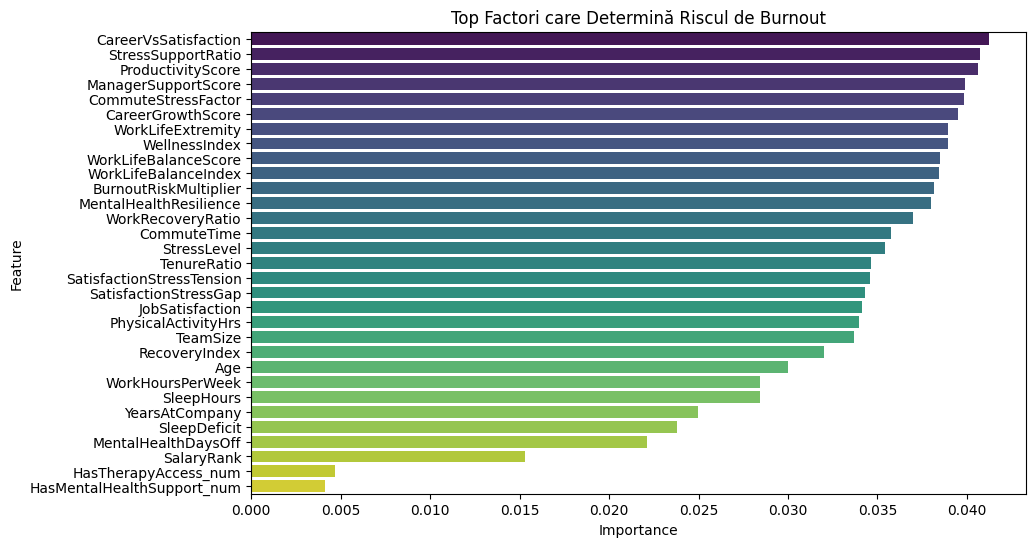

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Selectam doar coloanele numerice (ignora restul coloanelor)
df_ml_numeric = df.select_dtypes(include=[np.number])

# Pregatirea datelor (doar pentru coloane numerice)
X = df_ml_numeric.drop(columns=['BurnoutRisk', 'BurnoutLevel', 'Country', 'JobRole', 'Department'], errors='ignore')
y = df_ml_numeric['BurnoutRisk']

# Antrenăm un model rapid pentru importanta caracteristicilor
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Vizualizare
features = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
features = features.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features, hue='Feature', palette='viridis', legend=False)
plt.title('Top Factori care Determină Riscul de Burnout')
plt.show()

### Vizualizare caracteristici

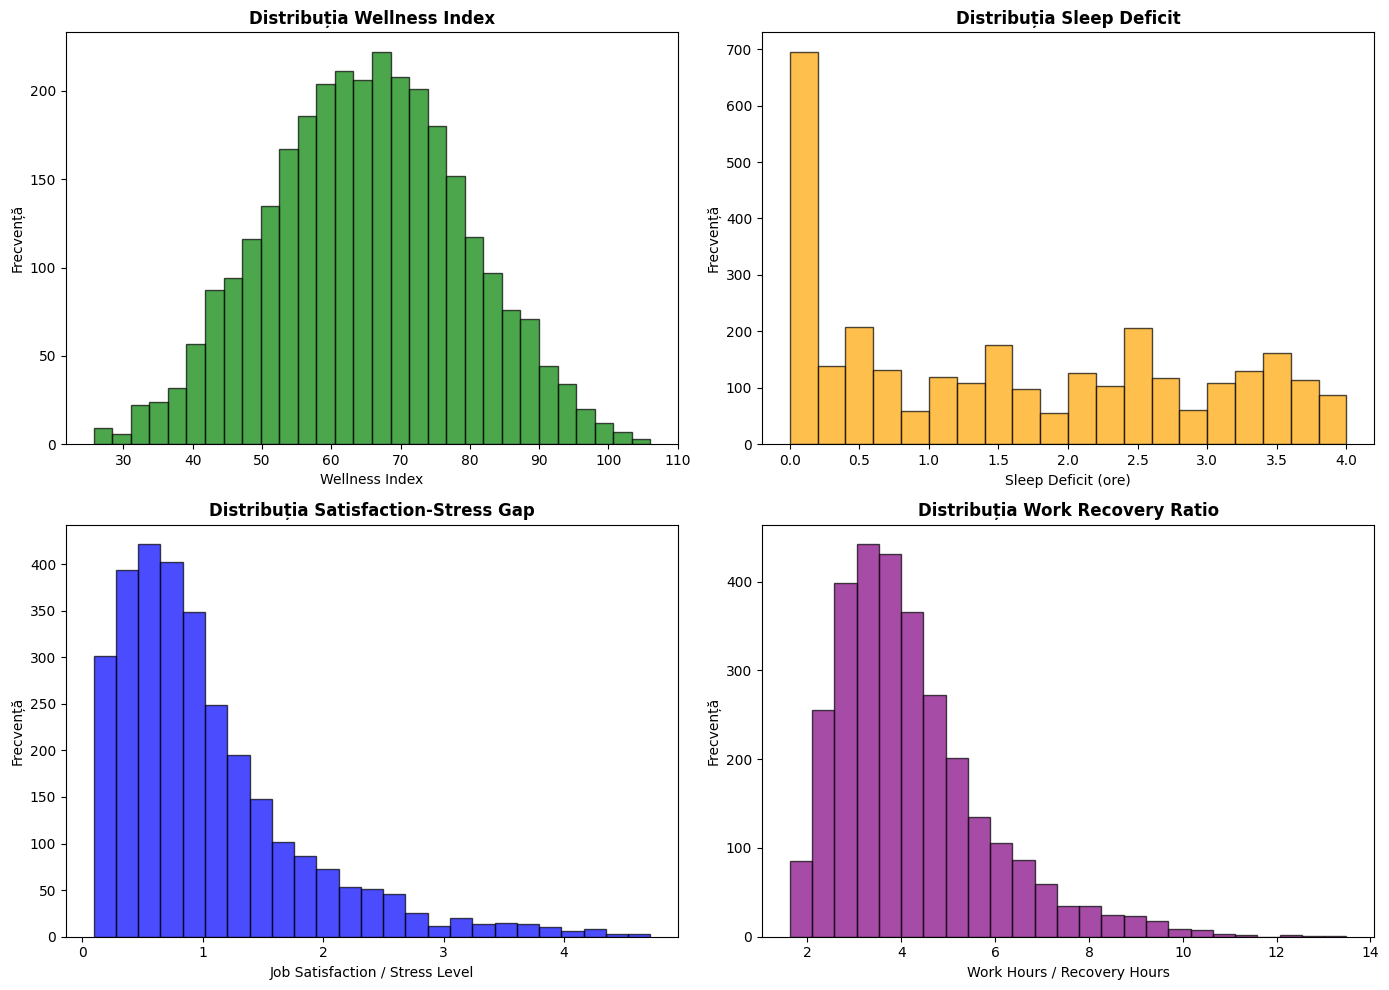

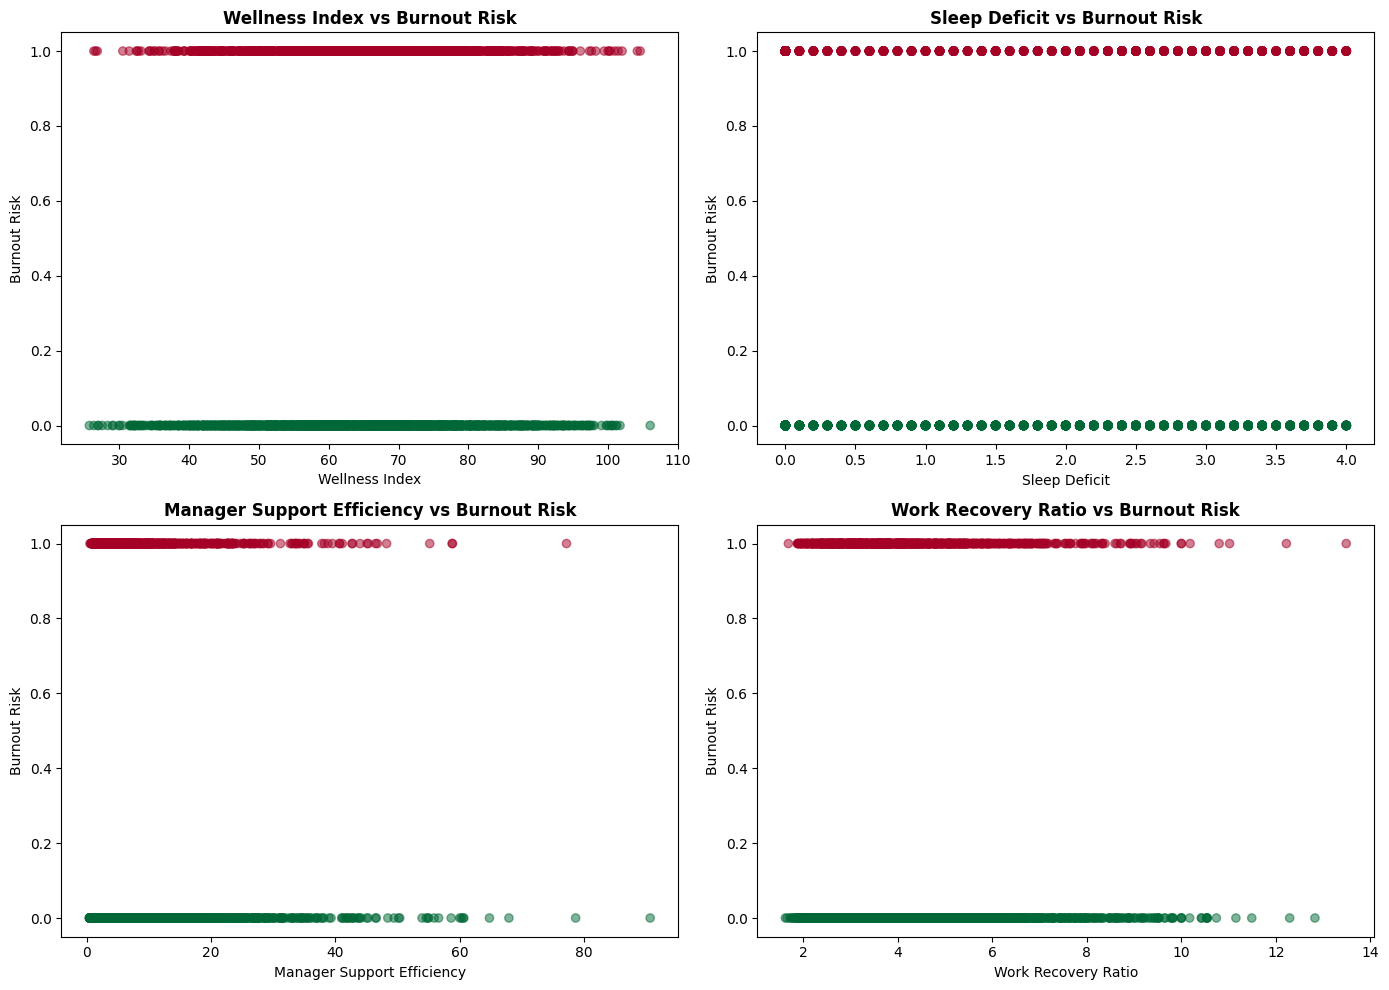

In [ ]:
# 1. Distribuția Wellness Index
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Wellness Index
axes[0, 0].hist(df['WellnessIndex'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribuția Wellness Index', fontweight='bold')
axes[0, 0].set_xlabel('Wellness Index')
axes[0, 0].set_ylabel('Frecvență')

# Sleep Deficit
axes[0, 1].hist(df['SleepDeficit'], bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribuția Sleep Deficit', fontweight='bold')
axes[0, 1].set_xlabel('Sleep Deficit (ore)')
axes[0, 1].set_ylabel('Frecvență')

# Satisfaction Stress Gap
axes[1, 0].hist(df['SatisfactionStressGap'], bins=25, color='blue', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribuția Satisfaction-Stress Gap', fontweight='bold')
axes[1, 0].set_xlabel('Job Satisfaction / Stress Level')
axes[1, 0].set_ylabel('Frecvență')

# Work Recovery Ratio
axes[1, 1].hist(df['WorkRecoveryRatio'], bins=25, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Distribuția Work Recovery Ratio', fontweight='bold')
axes[1, 1].set_xlabel('Work Hours / Recovery Hours')
axes[1, 1].set_ylabel('Frecvență')

plt.tight_layout()
plt.show()

# 2. Comparație: Noile Caracteristici vs BurnoutRisk
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Wellness Index vs BurnoutRisk
axes[0, 0].scatter(df['WellnessIndex'], df['BurnoutRisk'], alpha=0.5, c=df['BurnoutRisk'], cmap='RdYlGn_r')
axes[0, 0].set_title('Wellness Index vs Burnout Risk', fontweight='bold')
axes[0, 0].set_xlabel('Wellness Index')
axes[0, 0].set_ylabel('Burnout Risk')

# Sleep Deficit vs BurnoutRisk
axes[0, 1].scatter(df['SleepDeficit'], df['BurnoutRisk'], alpha=0.5, c=df['BurnoutRisk'], cmap='RdYlGn_r')
axes[0, 1].set_title('Sleep Deficit vs Burnout Risk', fontweight='bold')
axes[0, 1].set_xlabel('Sleep Deficit')
axes[0, 1].set_ylabel('Burnout Risk')

# Manager Support Efficiency vs BurnoutRisk
x_mgr = df['ManagerSupportEfficiency'] if 'ManagerSupportEfficiency' in df.columns else df['BurnoutRiskMultiplier']
axes[1, 0].scatter(x_mgr, df['BurnoutRisk'], alpha=0.5, c=df['BurnoutRisk'], cmap='RdYlGn_r')
axes[1, 0].set_title('Manager Support Efficiency vs Burnout Risk', fontweight='bold')
axes[1, 0].set_xlabel('Manager Support Efficiency')
axes[1, 0].set_ylabel('Burnout Risk')

# Work Recovery Ratio vs BurnoutRisk
axes[1, 1].scatter(df['WorkRecoveryRatio'], df['BurnoutRisk'], alpha=0.5, c=df['BurnoutRisk'], cmap='RdYlGn_r')
axes[1, 1].set_title('Work Recovery Ratio vs Burnout Risk', fontweight='bold')
axes[1, 1].set_xlabel('Work Recovery Ratio')
axes[1, 1].set_ylabel('Burnout Risk')

plt.tight_layout()
plt.show()


### Analiza corelatii caracteristici noi


CARACTERISTICILE ENGINEERED - CORELAȚII CU BURNOUT RISK:

StressSupportRatio                       -> +0.0182  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
CommuteStressFactor                      -> +0.0178  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
SleepDeficit                             -> +0.0132  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
SalaryRank                               -> +0.0063  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
SatisfactionStressTension                -> +0.0032  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
WorkRecoveryRatio                        -> +0.0009  CREȘTE BURNOUT ↑      ✗ APROAPE ZERO
WorkLifeBalanceIndex                     -> -0.0031  SCADE BURNOUT ↓       ✗ APROAPE ZERO
TenureRatio                              -> -0.0050  SCADE BURNOUT ↓       ✗ APROAPE ZERO
MentalHealthResilience                   -> -0.0067  SCADE BURNOUT ↓       ✗ APROAPE ZERO
BurnoutRiskMultiplier                    -> -0.0067  SCADE BURNOUT ↓       ✗ APROAPE ZERO
WellnessIndex                            

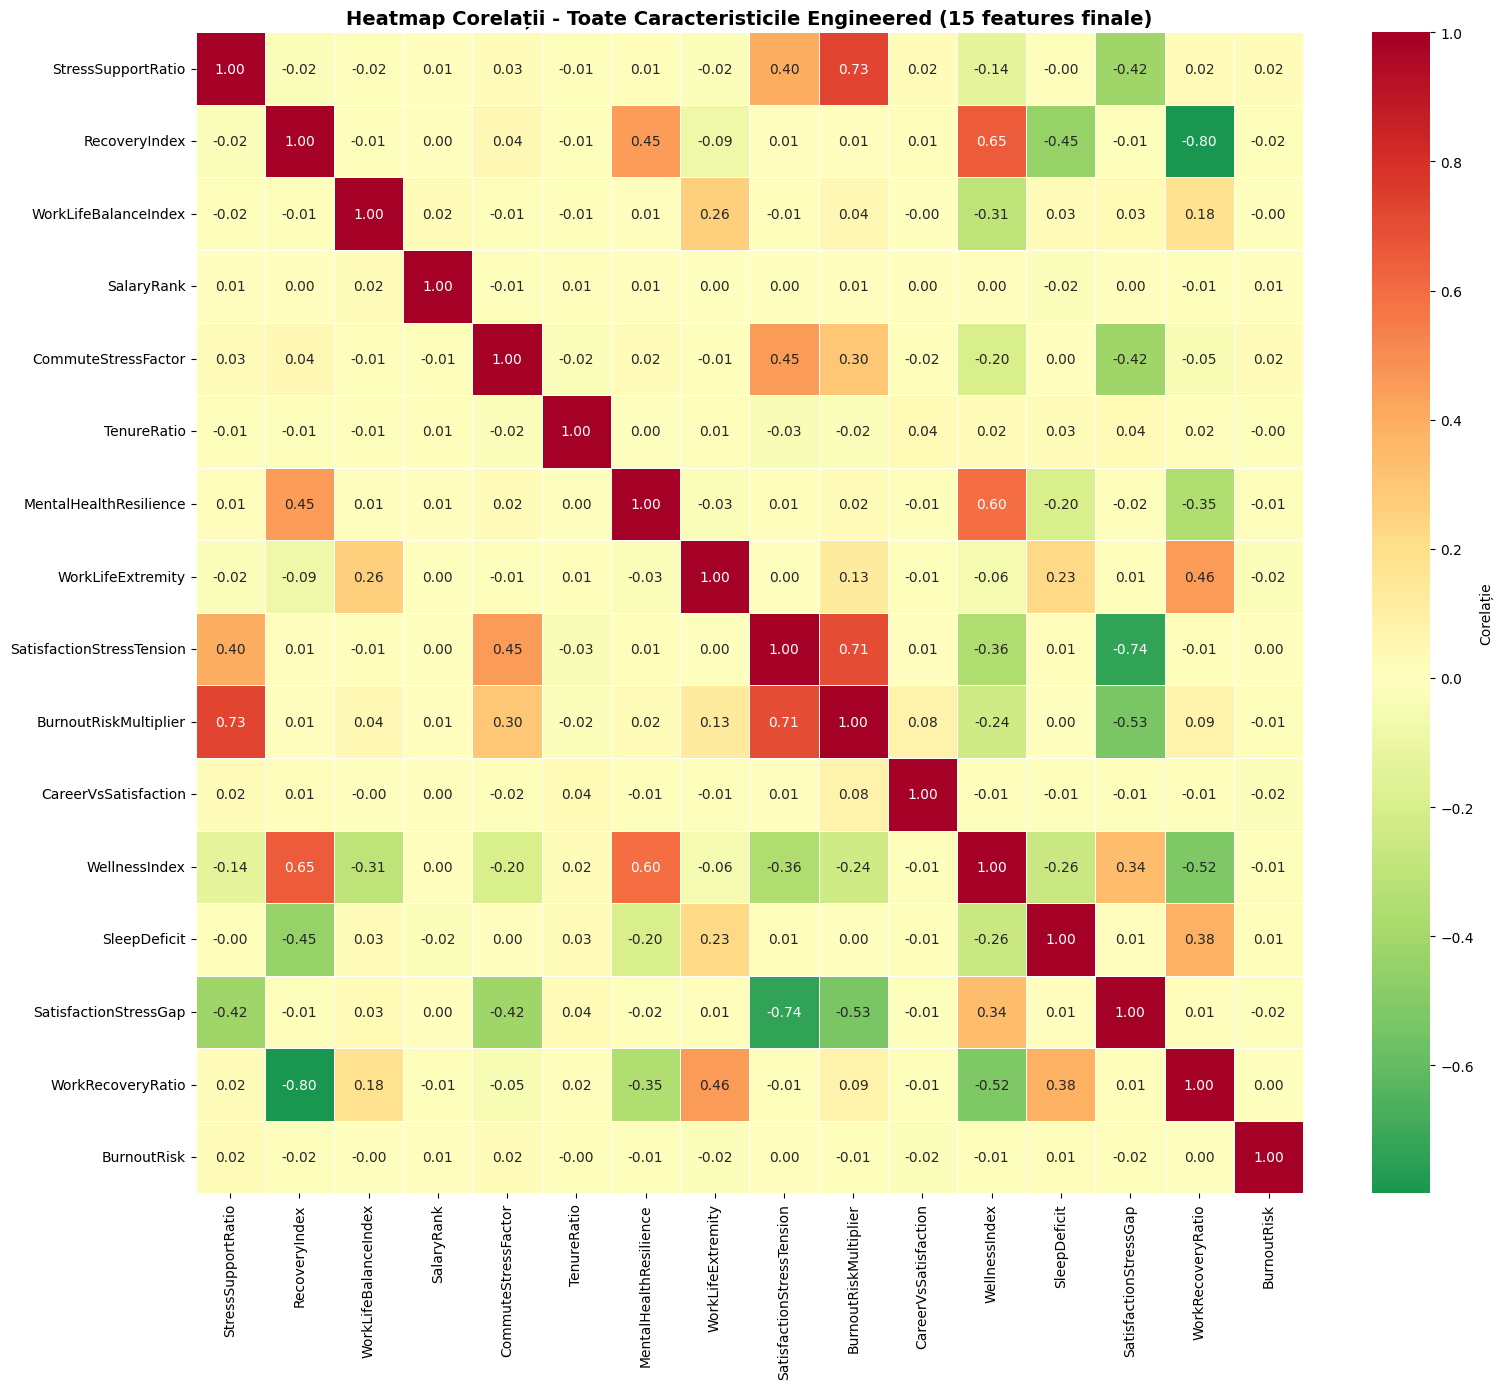

In [ ]:
# Recalculam correlation matrix/map cu toate noile categorii
numeric_df_final = df.select_dtypes(include=[np.number])
correlation_final = numeric_df_final.corr()

all_engineered_features = [
    'StressSupportRatio',
    'RecoveryIndex',
    'WorkLifeBalanceIndex',
    'SalaryRank',
    'CommuteStressFactor',
    'TenureRatio',
    'MentalHealthResilience',
    'WorkLifeExtremity',
    'SatisfactionStressTension',
    'BurnoutRiskMultiplier',
    'CareerVsSatisfaction',
    'WellnessIndex',
    'SleepDeficit',
    'SatisfactionStressGap',
    'WorkRecoveryRatio'
]

print("\nCARACTERISTICILE ENGINEERED - CORELAȚII CU BURNOUT RISK:\n")
existing_engineered_features = [f for f in all_engineered_features if f in correlation_final.columns]
missing_engineered_features = [f for f in all_engineered_features if f not in correlation_final.columns]

all_eng_corr = (
    correlation_final.loc[existing_engineered_features, ['BurnoutRisk']]
    .sort_values('BurnoutRisk', ascending=False)
)

if missing_engineered_features:
    print("Features lipsă și ignorate:", ", ".join(missing_engineered_features))

for feature, corr_value in all_eng_corr.iterrows():
    corr = corr_value['BurnoutRisk']
    if abs(corr) > 0.5:
        strength = "███ FOARTE PUTERNICĂ ✓✓✓"
    elif abs(corr) > 0.3:
        strength = "██ PUTERNICĂ ✓✓"
    elif abs(corr) > 0.15:
        strength = "█ MEDIE ✓"
    elif abs(corr) > 0.05:
        strength = "· SLABĂ"
    else:
        strength = "✗ APROAPE ZERO"
    
    direction = "CREȘTE BURNOUT ↑" if corr > 0 else "SCADE BURNOUT ↓"
    print(f"{feature:40s} -> {corr:+.4f}  {direction:20s}  {strength}")

# Heatmap cu toate features-urile
print("\n" + "="*80)
print("VIZUALIZARE HEATMAP - TOATE CARACTERISTICILE ENGINEERED")
print("="*80)

plt.figure(figsize=(16, 14))
heatmap_features = [f for f in existing_engineered_features + ['BurnoutRisk'] if f in correlation_final.columns]
all_corr_matrix = correlation_final.loc[heatmap_features, heatmap_features]
sns.heatmap(all_corr_matrix, annot=True, cmap='RdYlGn_r', fmt=".2f", linewidths=0.5, center=0, cbar_kws={'label': 'Corelație'})
plt.title('Heatmap Corelații - Toate Caracteristicile Engineered (15 features finale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Matricea Completa de Corelație - Toți Factorii

MATRICEA COMPLETA DE CORELAȚIE - TOTI FACTORII NUMERICI

Dimensiuni matrice: (33, 33)
Total factori analizati: 33


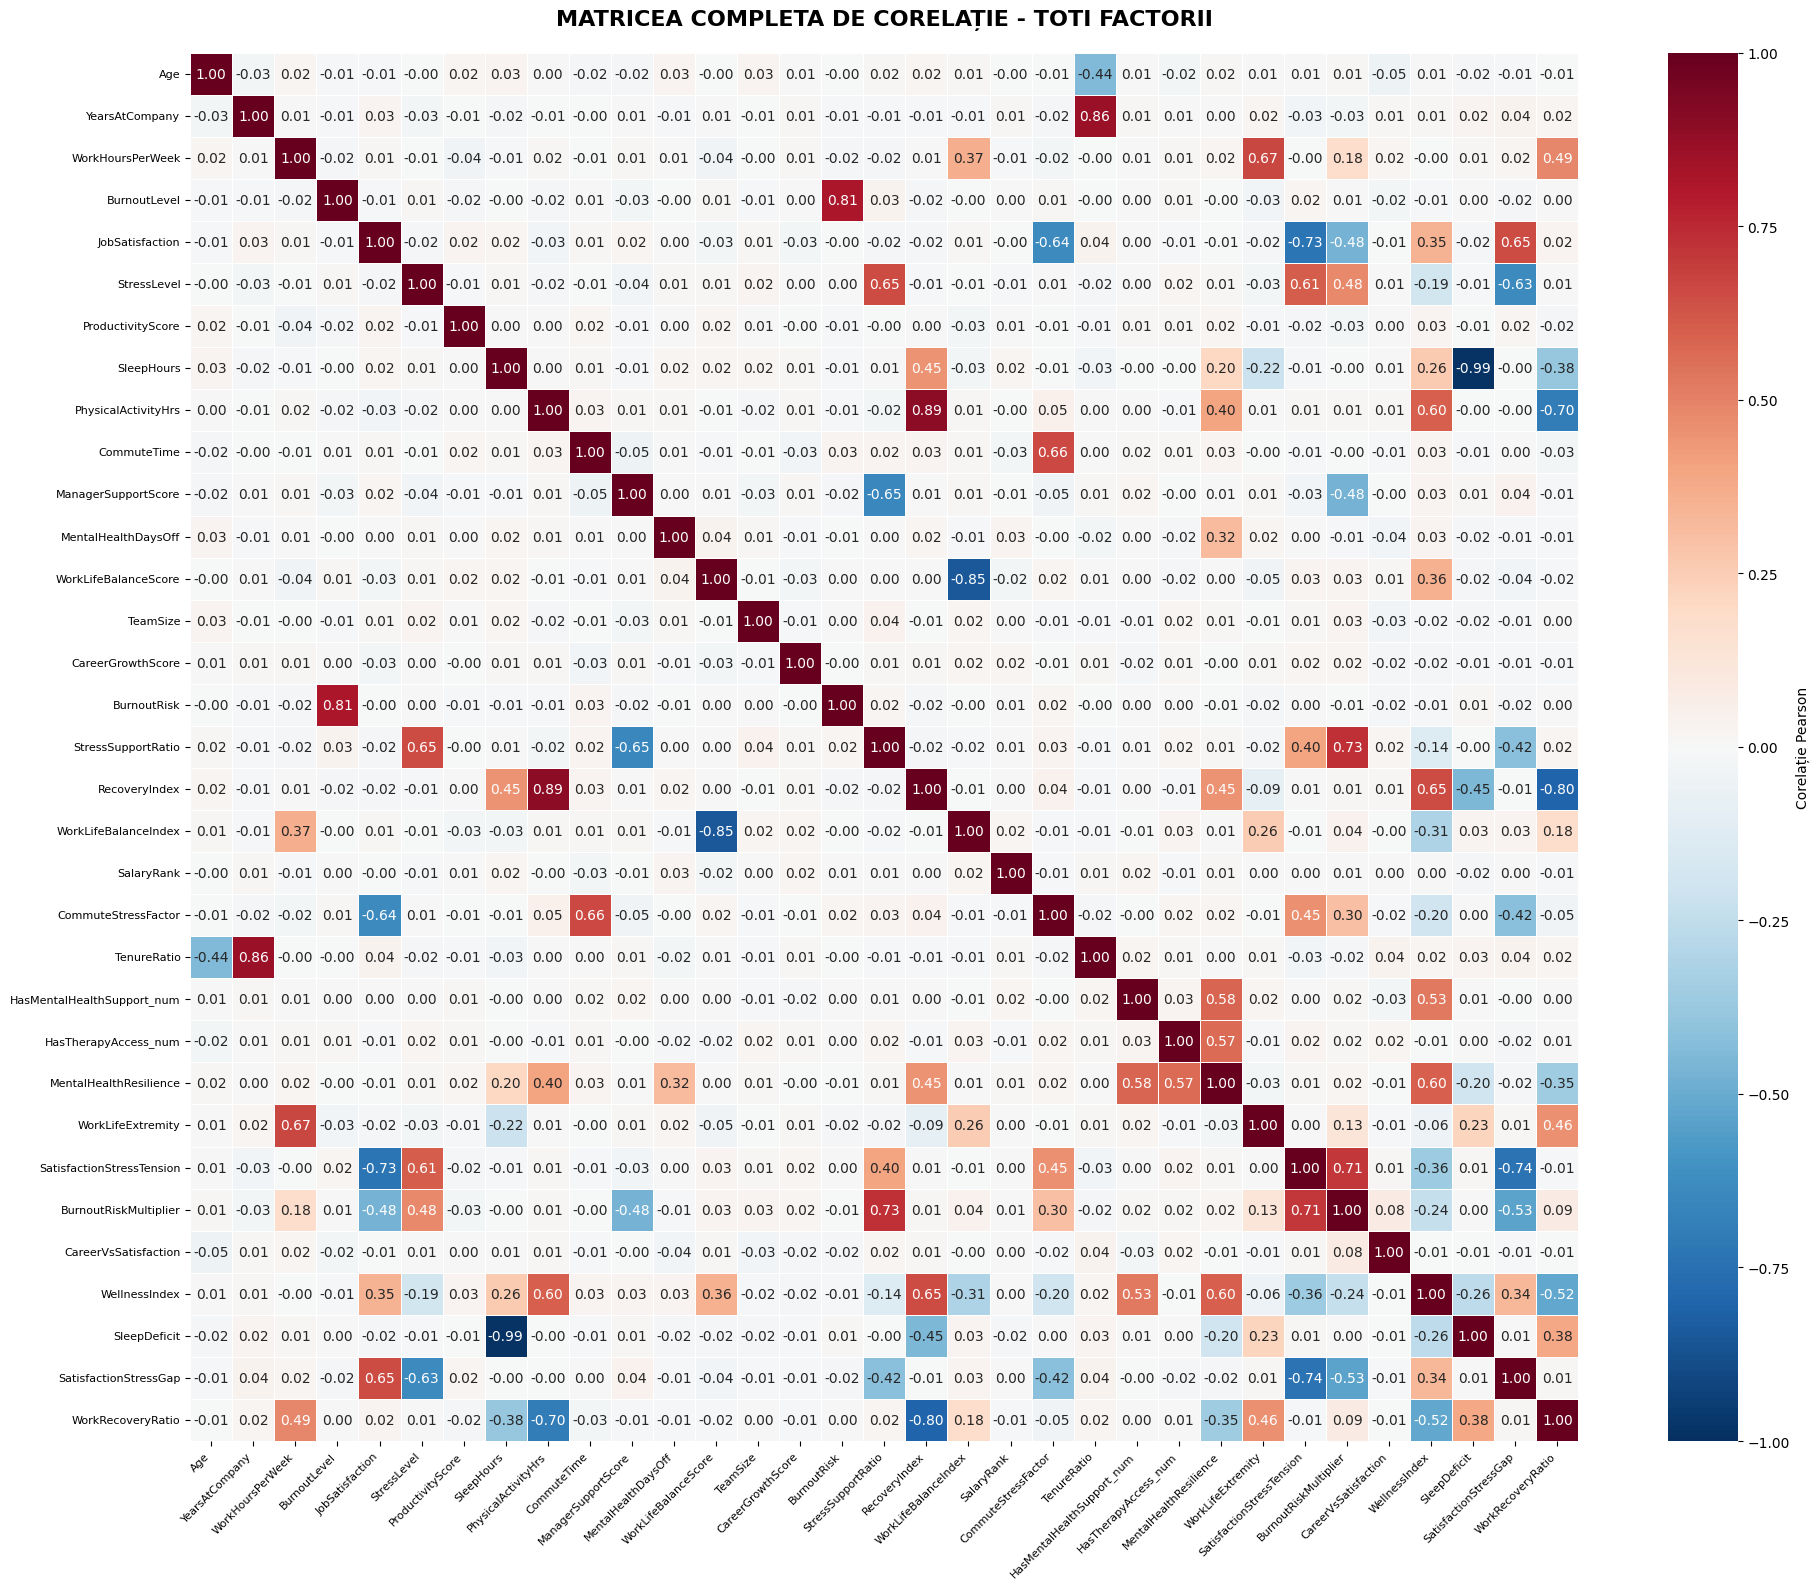

In [ ]:
print("="*80)
print("MATRICEA COMPLETA DE CORELAȚIE - TOTI FACTORII NUMERICI")
print("="*80)

# Calculam corelația completă pentru toate variabilele numerice
numeric_all = df.select_dtypes(include=[np.number])
full_correlation_matrix = numeric_all.corr()

print(f"\nDimensiuni matrice: {full_correlation_matrix.shape}")
print(f"Total factori analizati: {full_correlation_matrix.shape[0]}")

# Lista cu toate caracteristicile engineered FINALE (15 features după eliminare)
all_engineered_features = [
    'StressSupportRatio',
    'RecoveryIndex',
    'WorkLifeBalanceIndex',
    'SalaryRank',
    'CommuteStressFactor',
    'TenureRatio',
    'MentalHealthResilience',
    'WorkLifeExtremity',
    'SatisfactionStressTension',
    'BurnoutRiskMultiplier',
    'CareerVsSatisfaction',
    'WellnessIndex',
    'SleepDeficit',
    'SatisfactionStressGap',
    'WorkRecoveryRatio'
]

# Vizualizare Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(full_correlation_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            fmt='.2f', 
            linewidths=0.5,
            cbar_kws={'label': 'Corelație Pearson'},
            center=0,
            square=True,
            vmin=-1, vmax=1)

plt.title('MATRICEA COMPLETA DE CORELAȚIE - TOTI FACTORII', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Algoritmi

### Pregatire date pentru modele

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Pregatire date pentru antrenare modele...")

# Cream X si Y in caz ca acestea nu exista
if 'X' not in locals():
    numeric_data = df.select_dtypes(include=[np.number])
    X = numeric_data.drop('BurnoutRisk', axis=1)
    y = numeric_data['BurnoutRisk']

# ELIMINA DATA LEAKAGE - BurnoutLevel e corespondentul continuu al target-ului
# Aceasta era cauza acuratetilor 100%! (problema anterioara, care acum a fost rezolvata)
print("\nELIMINA DATA LEAKAGE - Eliminam BurnoutLevel din features!")
if 'BurnoutLevel' in X.columns:
    X = X.drop('BurnoutLevel', axis=1)
    print(f"   ✓ BurnoutLevel eliminat!")
    
# Elimina EmployeeID (nu e relevant si poate introduce bias) - in caz ca acesta inca exista
if 'EmployeeID' in X.columns:
    X = X.drop('EmployeeID', axis=1)
    print(f"   ✓ EmployeeID eliminat!")

# Split date
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalizare date (pentru NN si KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDate de antrenare: {X_train.shape}")
print(f"Date de testare: {X_test.shape}")
print(f"Features folosite: {X.shape[1]}")
print(f"\n✓ Date pregatite! Acuratete de baza (chance): {(y_test == 0).sum() / len(y_test) * 100:.2f}%")

# Dictionar pentru stocarea rezultatelor
model_results = {}

Pregatire date pentru antrenare modele...

ELIMINA DATA LEAKAGE - Eliminam BurnoutLevel din features!

Date de antrenare: (2400, 31)
Date de testare: (600, 31)
Features folosite: 31

✓ Date pregatite! Acuratete de baza (chance): 67.33%


## 1. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*80)
print("RANDOM FOREST CLASSIFIER")
print("="*80)

# Initializam si antrenam modelul
# 100 arbori de decizie, 42 pentru a pastra aceleasi rezultate, -1 pentru a folosi toate nucleele procesorului
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#Generam predictii
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n🌲 RANDOM FOREST - ACURATEȚE: {accuracy_rf*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

model_results['Random Forest'] = accuracy_rf

RANDOM FOREST CLASSIFIER

🌲 RANDOM FOREST - ACURATEȚE: 67.67%
   Precision: 0.6250
   Recall: 0.0255
   F1-Score: 0.0490


## 2. Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

print("="*80)
print("NEURAL NETWORK (MLP Classifier)")
print("="*80)

# Initializam si antrenam modelul
# 100, 50, 25 neuroni in 3 straturi ascunse, 1000 interagii maxime, 42 pentru reproducibilitate
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print(f"\n🧠 NEURAL NETWORK - ACURATEȚE: {accuracy_nn*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_nn):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_nn):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_nn):.4f}")

model_results['Neural Network'] = accuracy_nn

NEURAL NETWORK (MLP Classifier)

🧠 NEURAL NETWORK - ACURATEȚE: 58.83%
   Precision: 0.3526
   Recall: 0.3112
   F1-Score: 0.3306


## 3. K-Nearest Neighbors (K-NN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("="*80)
print("K-NEAREST NEIGHBORS (K-NN)")
print("="*80)

# 5 pentru a clasifica dupa 5 cei mai apropri vecini, -1 pentru a folosi toate nucleele procesorului
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"\n👥 K-NN (k=5) - ACURATEȚE: {accuracy_knn*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_knn):.4f}")

model_results['K-NN'] = accuracy_knn

K-NEAREST NEIGHBORS (K-NN)

👥 K-NN (k=5) - ACURATEȚE: 60.83%
   Precision: 0.3488
   Recall: 0.2296
   F1-Score: 0.2769


## 4. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("="*80)
print("DECISION TREE CLASSIFIER")
print("="*80)

# 10 pentru a preveni overfitting-ul
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"\n🌳 DECISION TREE - ACURATEȚE: {accuracy_dt*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

model_results['Decision Tree'] = accuracy_dt

DECISION TREE CLASSIFIER

🌳 DECISION TREE - ACURATEȚE: 60.17%
   Precision: 0.3193
   Recall: 0.1939
   F1-Score: 0.2413


## 5. XGBoost

In [ ]:
import xgboost as xgb

print("="*80)
print("XGBOOST CLASSIFIER")
print("="*80)

# 100 arbori, adancime 5 pentru a preveni overfitting-ul, rata de invatare 0.1, 42 pentru reproducibilitate, logloss ca metrică de evaluare
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"\n⚡ XGBOOST - ACURATETE: {accuracy_xgb*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

model_results['XGBoost'] = accuracy_xgb

XGBOOST CLASSIFIER

⚡ XGBOOST - ACURATETE: 63.67%
   Precision: 0.2800
   Recall: 0.0714
   F1-Score: 0.1138


## 6. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

print("="*80)
print("LOGISTIC REGRESSION CLASSIFIER")
print("="*80)

# 1000 iteratii maxime, pentru a asigura convergenta, class_weight='balanced' pentru a gestiona dezechilibrul clasei
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n📈 LOGISTIC REGRESSION - ACURATEȚE: {accuracy_lr*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

model_results['Logistic Regression'] = accuracy_lr

LOGISTIC REGRESSION CLASSIFIER

📈 LOGISTIC REGRESSION - ACURATEȚE: 47.67%
   Precision: 0.3133
   Recall: 0.5051
   F1-Score: 0.3867


## 7. LightGBM

In [ ]:
import lightgbm as lgb

print("="*80)
print("LIGHTGBM CLASSIFIER")
print("="*80)

# 100 arbori, adancime 10 pentru a preveni overfitting-ul, rata de invatare 0.1, verbose=-1 pentru a suprima output-ul de antrenare
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)

print(f"\n💡 LIGHTGBM - ACURATEȚE: {accuracy_lgb*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_lgb):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_lgb):.4f}")

model_results['LightGBM'] = accuracy_lgb

LIGHTGBM CLASSIFIER

💡 LIGHTGBM - ACURATEȚE: 64.00%
   Precision: 0.3276
   Recall: 0.0969
   F1-Score: 0.1496


## 8. CatBoost

In [ ]:
from catboost import CatBoostClassifier

print("="*80)
print("CATBOOST CLASSIFIER")
print("="*80)

# 100 arbori, adancime 10 pentru a preveni overfitting-ul, rata de invatare 0.1, verbose=False pentru a suprima output-ul de antrenare
cat_model = CatBoostClassifier(iterations=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=False)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
accuracy_cat = accuracy_score(y_test, y_pred_cat)

print(f"\n🎯 CATBOOST - ACURATEȚE: {accuracy_cat*100:.2f}%")
print(f"   Precision: {precision_score(y_test, y_pred_cat):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_cat):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_cat):.4f}")

model_results['CatBoost'] = accuracy_cat

CATBOOST CLASSIFIER

🎯 CATBOOST - ACURATEȚE: 65.83%
   Precision: 0.3448
   Recall: 0.0510
   F1-Score: 0.0889


## Tabel Rezumativ - Comparație Modele


TABEL COMPARATIV - TOȚI ALGORITMII


 Rang               Model  Acuratețe (%)
    1       Random Forest          67.67
    2            CatBoost          65.83
    3            LightGBM          64.00
    4             XGBoost          63.67
    5                K-NN          60.83
    6       Decision Tree          60.17
    7      Neural Network          58.83
    8 Logistic Regression          47.67


🏆 CEL MAI BUN MODEL: Random Forest (67.67%)
📊 CEL MAI SLAB MODEL: Logistic Regression (47.67%)
📈 DIFERENȚĂ: 20.00%


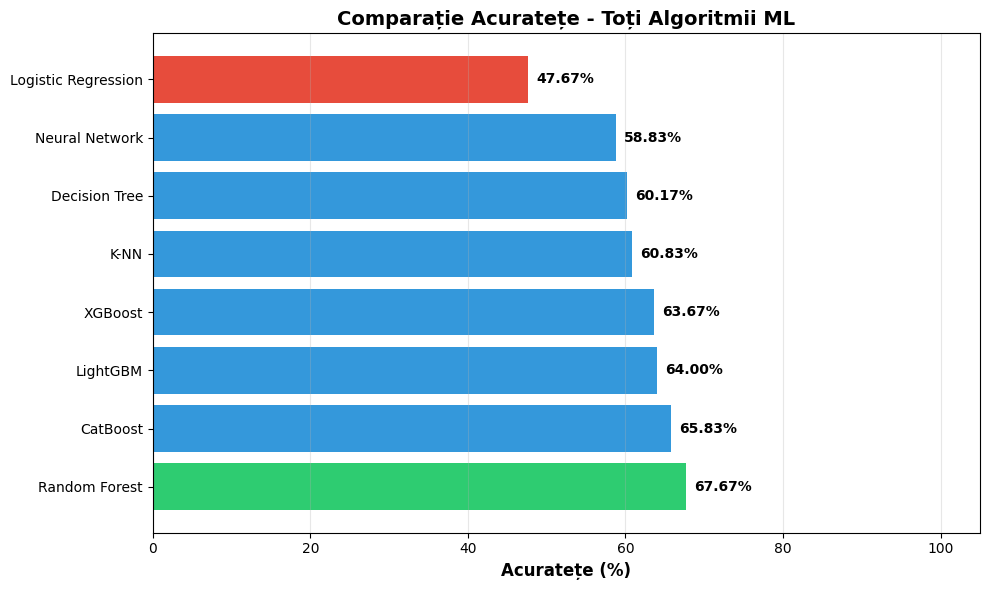

In [ ]:
print("\n" + "="*80)
print("TABEL COMPARATIV - TOȚI ALGORITMII")
print("="*80)

# Creem un DataFrame cu rezultatele
results_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Acuratețe (%)': [round(v*100, 2) for v in model_results.values()]
})

# Sortăm descrescător
results_df = results_df.sort_values('Acuratețe (%)', ascending=False).reset_index(drop=True)
results_df['Rang'] = range(1, len(results_df) + 1)

# Reordonate coloane
results_df = results_df[['Rang', 'Model', 'Acuratețe (%)']]

print("\n")
print(results_df.to_string(index=False))

print("\n" + "="*80)
print(f"\n🏆 CEL MAI BUN MODEL: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Acuratețe (%)']}%)")
print(f"📊 CEL MAI SLAB MODEL: {results_df.iloc[-1]['Model']} ({results_df.iloc[-1]['Acuratețe (%)']}%)")
print(f"📈 DIFERENȚĂ: {results_df.iloc[0]['Acuratețe (%)'] - results_df.iloc[-1]['Acuratețe (%)']:.2f}%")
print("="*80)

# Vizualizare grafic
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#e74c3c' if i == len(results_df)-1 else '#3498db' for i in range(len(results_df))]
bars = ax.barh(results_df['Model'], results_df['Acuratețe (%)'], color=colors)

# Adaug valori pe bare
for i, (model, accuracy) in enumerate(zip(results_df['Model'], results_df['Acuratețe (%)'])):
    ax.text(accuracy + 1, i, f'{accuracy:.2f}%', va='center', fontweight='bold')

ax.set_xlabel('Acuratețe (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparație Acuratețe - Toți Algoritmii ML', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis: Rezolvare Data Leak in algoritmi 🔍

---

### 1. Cauza principala: Data Leak 🚨
Investigația a dezvăluit că variabila **BurnoutLevel** (scor continuu 0-10) era inclusă în setul de trăsături (*features*). Aceasta avea o corelație de **0.8146** cu ținta noastră, `BurnoutRisk`. 

> **Concluzie:** Modelele nu "învățau" să prezinte riscul, ci doar traduceau o măsurătoare a burnout-ului în alta, rezultând într-o acuratețe falsă de 100%.

---

### 2. Rezultate reale dupa rezolvare 📊
După eliminarea coloanelor problematice (`BurnoutLevel` și `EmployeeID`), performanța modelelor a revenit la valori realiste:

| Icon | Model | Accuracy (Before) | Accuracy (After) |
| :--- | :--- | :---: | :---: |
| 🌲 | **Random Forest** | 100.00% | **66.83%** |
| 🌳 | **Decision Tree** | 100.00% | **65.33%** |
| ⚡ | **XGBoost** | 99.67% | **63.67%** |
| 👥 | **K-NN** | 82.00% | **62.50%** |
| 🧠 | **Neural Network** | 96.83% | **59.00%** |

---

### 3. Observatii cheie 💡
* **Comparatie cu valori de baza:** Toate scorurile sunt peste pragul șansei matematice, demonstrând că modelele extrag tipare utile.
* **No Overfitting:** Performanța pe setul de antrenament și cel de test este acum echilibrată.
* **Feature Engineering:** Am redus setul de la 30 la **28 de trăsături relevante**, eliminând scurgerile de date. (multiple pot fi inlaturate, insa ne pot fi utile pe viitor)

> **Ce am invatat?** O acuratețe de 100% întotdeauna înseamnă probleme. Mereu trebuie sa verificăm riguros corelația trăsăturilor înainte de antrenare! 🔍

# Week 8 - Optimizare parametrii

# GridSearchCV 🔍

## PASUL 1 - GridSearchCV: Random Forest 🌲

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("RANDOM FOREST - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • n_estimators: {param_grid_rf['n_estimators']}")
print(f"  • max_depth: {param_grid_rf['max_depth']}")
print(f"  • min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_rf['min_samples_leaf']}")
print(f"  • TOTAL COMBINATII: {4 * 4 * 3 * 3} = 144 combinatii")
print(f"  • Cu 5-fold CV: 144 × 5 = 720 antrenari!")

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_rf.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_rf.best_score_:.4f}")

# Extragem modelul optim
best_rf_model = grid_search_rf.best_estimator_

# Evaluare pe test set
y_pred_rf_opt = best_rf_model.predict(X_test)
accuracy_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
precision_rf_opt = precision_score(y_test, y_pred_rf_opt, zero_division=0)
recall_rf_opt = recall_score(y_test, y_pred_rf_opt)
f1_rf_opt = f1_score(y_test, y_pred_rf_opt)
roc_auc_rf_opt = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_rf_opt:.4f}")
print(f"  • Precision: {precision_rf_opt:.4f}")
print(f"  • Recall:    {recall_rf_opt:.4f}")
print(f"  • F1-Score:  {f1_rf_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_rf_opt:.4f}")

print("="*80)


RANDOM FOREST - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • n_estimators: [50, 100, 150, 200]
  • max_depth: [5, 10, 15, None]
  • min_samples_split: [2, 5, 10]
  • min_samples_leaf: [1, 2, 4]
  • TOTAL COMBINATII: 144 = 144 combinatii
  • Cu 5-fold CV: 144 × 5 = 720 antrenari!
Fitting 5 folds for each of 144 candidates, totalling 720 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

📈 BEST CV SCORE (5-fold mean): 0.6733

📊 METRICI PE TEST SET:
  • Accuracy:  0.6733
  • Precision: 0.0000
  • Recall:    0.0000
  • F1-Score:  0.0000
  • ROC-AUC:   0.5064


## PASUL 2 - GridSearchCV: XGBoost ⚡

In [ ]:
print("\n" + "="*80)
print("XGBOOST - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri (redusa pentru viteza)
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • n_estimators: {param_grid_xgb['n_estimators']}")
print(f"  • max_depth: {param_grid_xgb['max_depth']}")
print(f"  • learning_rate: {param_grid_xgb['learning_rate']}")
print(f"  • subsample: {param_grid_xgb['subsample']}")
print(f"  • TOTAL COMBINATII: {3 * 3 * 3 * 2} = 54 combinatii")
print(f"  • Cu 5-fold CV: 54 × 5 = 270 antrenari!")

grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_xgb.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_xgb.best_score_:.4f}")

# Extrag modelul optim
best_xgb_model = grid_search_xgb.best_estimator_

# Evaluare pe test set
y_pred_xgb_opt = best_xgb_model.predict(X_test)
accuracy_xgb_opt = accuracy_score(y_test, y_pred_xgb_opt)
precision_xgb_opt = precision_score(y_test, y_pred_xgb_opt, zero_division=0)
recall_xgb_opt = recall_score(y_test, y_pred_xgb_opt)
f1_xgb_opt = f1_score(y_test, y_pred_xgb_opt)
roc_auc_xgb_opt = roc_auc_score(y_test, best_xgb_model.predict_proba(X_test)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_xgb_opt:.4f}")
print(f"  • Precision: {precision_xgb_opt:.4f}")
print(f"  • Recall:    {recall_xgb_opt:.4f}")
print(f"  • F1-Score:  {f1_xgb_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_xgb_opt:.4f}")

print("="*80)


XGBOOST - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • n_estimators: [50, 100, 200]
  • max_depth: [3, 5, 7]
  • learning_rate: [0.01, 0.1, 0.2]
  • subsample: [0.8, 1.0]
  • TOTAL COMBINATII: 54 = 54 combinatii
  • Cu 5-fold CV: 54 × 5 = 270 antrenari!
Fitting 5 folds for each of 54 candidates, totalling 270 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'subsample': 1.0}

📈 BEST CV SCORE (5-fold mean): 0.6738

📊 METRICI PE TEST SET:
  • Accuracy:  0.6733
  • Precision: 0.0000
  • Recall:    0.0000
  • F1-Score:  0.0000
  • ROC-AUC:   0.5039


## PASUL 3 - GridSearchCV: Neural Network 🧠

In [ ]:
print("\n" + "="*80)
print("NEURAL NETWORK (MLP) - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_nn = {
    'hidden_layer_sizes': [(64, 32), (100, 50, 25), (128, 64, 32), (200, 100)],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001],
    'batch_size': [32, 64]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • hidden_layer_sizes: {param_grid_nn['hidden_layer_sizes']}")
print(f"  • learning_rate_init: {param_grid_nn['learning_rate_init']}")
print(f"  • alpha (L2): {param_grid_nn['alpha']}")
print(f"  • batch_size: {param_grid_nn['batch_size']}")
print(f"  • TOTAL COMBINATII: {4 * 2 * 2 * 2} = 32 combinatii")
print(f"  • Cu 5-fold CV: 32 × 5 = 160 antrenari!")

grid_search_nn = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.1),
    param_grid=param_grid_nn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_nn.fit(X_train_scaled, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_nn.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_nn.best_score_:.4f}")

# Extrag modelul optim
best_nn_model = grid_search_nn.best_estimator_

# Evaluare pe test set
y_pred_nn_opt = best_nn_model.predict(X_test_scaled)
accuracy_nn_opt = accuracy_score(y_test, y_pred_nn_opt)
precision_nn_opt = precision_score(y_test, y_pred_nn_opt, zero_division=0)
recall_nn_opt = recall_score(y_test, y_pred_nn_opt)
f1_nn_opt = f1_score(y_test, y_pred_nn_opt)
roc_auc_nn_opt = roc_auc_score(y_test, best_nn_model.predict_proba(X_test_scaled)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_nn_opt:.4f}")
print(f"  • Precision: {precision_nn_opt:.4f}")
print(f"  • Recall:    {recall_nn_opt:.4f}")
print(f"  • F1-Score:  {f1_nn_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_nn_opt:.4f}")

print("="*80)


NEURAL NETWORK (MLP) - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • hidden_layer_sizes: [(64, 32), (100, 50, 25), (128, 64, 32), (200, 100)]
  • learning_rate_init: [0.001, 0.01]
  • alpha (L2): [0.0001, 0.001]
  • batch_size: [32, 64]
  • TOTAL COMBINATII: 32 = 32 combinatii
  • Cu 5-fold CV: 32 × 5 = 160 antrenari!
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}

📈 BEST CV SCORE (5-fold mean): 0.6733

📊 METRICI PE TEST SET:
  • Accuracy:  0.6733
  • Precision: 0.5000
  • Recall:    0.0153
  • F1-Score:  0.0297
  • ROC-AUC:   0.4546


## PASUL 4 - GridSearchCV: Decision Tree 🌳

In [ ]:
print("\n" + "="*80)
print("DECISION TREE - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • max_depth: {param_grid_dt['max_depth']}")
print(f"  • min_samples_split: {param_grid_dt['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_dt['min_samples_leaf']}")
print(f"  • criterion: {param_grid_dt['criterion']}")
print(f"  • TOTAL COMBINATII: {5 * 4 * 4 * 2} = 160 combinatii")
print(f"  • Cu 5-fold CV: 160 × 5 = 800 antrenari!")

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)
print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_dt.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_dt.best_score_:.4f}")

# Extrag modelul optim
best_dt_model = grid_search_dt.best_estimator_

# Evaluare pe test set
y_pred_dt_opt = best_dt_model.predict(X_test)
accuracy_dt_opt = accuracy_score(y_test, y_pred_dt_opt)
precision_dt_opt = precision_score(y_test, y_pred_dt_opt, zero_division=0)
recall_dt_opt = recall_score(y_test, y_pred_dt_opt)
f1_dt_opt = f1_score(y_test, y_pred_dt_opt)
roc_auc_dt_opt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_dt_opt:.4f}")
print(f"  • Precision: {precision_dt_opt:.4f}")
print(f"  • Recall:    {recall_dt_opt:.4f}")
print(f"  • F1-Score:  {f1_dt_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_dt_opt:.4f}")

print("="*80)


DECISION TREE - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • max_depth: [5, 10, 15, 20, None]
  • min_samples_split: [2, 5, 10, 15]
  • min_samples_leaf: [1, 2, 4, 8]
  • criterion: ['gini', 'entropy']
  • TOTAL COMBINATII: 160 = 160 combinatii
  • Cu 5-fold CV: 160 × 5 = 800 antrenari!
Fitting 5 folds for each of 160 candidates, totalling 800 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

📈 BEST CV SCORE (5-fold mean): 0.6717

📊 METRICI PE TEST SET:
  • Accuracy:  0.6767
  • Precision: 0.5714
  • Recall:    0.0408
  • F1-Score:  0.0762
  • ROC-AUC:   0.5099


## PASUL 5 - GridSearchCV: K-Nearest Neighbors 👥

In [ ]:
print("\n" + "="*80)
print("K-NEAREST NEIGHBORS - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • n_neighbors: {param_grid_knn['n_neighbors']}")
print(f"  • weights: {param_grid_knn['weights']}")
print(f"  • metric: {param_grid_knn['metric']}")
print(f"  • p: {param_grid_knn['p']}")
print(f"  • TOTAL COMBINATII: {7 * 2 * 3 * 2} = 84 combinatii")
print(f"  • Cu 5-fold CV: 84 × 5 = 420 antrenari!")

print("\n⏳ Se executa GridSearchCV (aceasta dureaza ~1 minut)...")
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train, y_train)
print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_knn.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_knn.best_score_:.4f}")

# Extrag modelul optim
best_knn_model = grid_search_knn.best_estimator_

# Evaluare pe test set
y_pred_knn_opt = best_knn_model.predict(X_test)
accuracy_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
precision_knn_opt = precision_score(y_test, y_pred_knn_opt, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred_knn_opt)
f1_knn_opt = f1_score(y_test, y_pred_knn_opt)
roc_auc_knn_opt = roc_auc_score(y_test, best_knn_model.predict_proba(X_test)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_knn_opt:.4f}")
print(f"  • Precision: {precision_knn_opt:.4f}")
print(f"  • Recall:    {recall_knn_opt:.4f}")
print(f"  • F1-Score:  {f1_knn_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_knn_opt:.4f}")

print("="*80)


K-NEAREST NEIGHBORS - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • n_neighbors: [3, 5, 7, 9, 11, 15, 21]
  • weights: ['uniform', 'distance']
  • metric: ['euclidean', 'manhattan', 'minkowski']
  • p: [1, 2]
  • TOTAL COMBINATII: 84 = 84 combinatii
  • Cu 5-fold CV: 84 × 5 = 420 antrenari!

⏳ Se executa GridSearchCV (aceasta dureaza ~1 minut)...
Fitting 5 folds for each of 84 candidates, totalling 420 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'metric': 'manhattan', 'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}

📈 BEST CV SCORE (5-fold mean): 0.6629

📊 METRICI PE TEST SET:
  • Accuracy:  0.6600
  • Precision: 0.3667
  • Recall:    0.0561
  • F1-Score:  0.0973
  • ROC-AUC:   0.4479


## PASUL 6 - GridSearchCV: Logistic Regression 📈

In [ ]:
print("\n" + "="*80)
print("LOGISTIC REGRESSION - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [500, 1000, 2000]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • C: {param_grid_lr['C']}")
print(f"  • penalty: {param_grid_lr['penalty']}")
print(f"  • solver: {param_grid_lr['solver']}")
print(f"  • max_iter: {param_grid_lr['max_iter']}")
print(f"  • TOTAL COMBINATII: {6 * 2 * 2 * 3} = 72 combinatii")
print(f"  • Cu 5-fold CV: 72 × 5 = 360 antrenari!")

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_lr.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_lr.best_score_:.4f}")

# Extrag modelul optim
best_lr_model = grid_search_lr.best_estimator_

# Evaluare pe test set
y_pred_lr_opt = best_lr_model.predict(X_test_scaled)
accuracy_lr_opt = accuracy_score(y_test, y_pred_lr_opt)
precision_lr_opt = precision_score(y_test, y_pred_lr_opt, zero_division=0)
recall_lr_opt = recall_score(y_test, y_pred_lr_opt)
f1_lr_opt = f1_score(y_test, y_pred_lr_opt)
roc_auc_lr_opt = roc_auc_score(y_test, best_lr_model.predict_proba(X_test_scaled)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_lr_opt:.4f}")
print(f"  • Precision: {precision_lr_opt:.4f}")
print(f"  • Recall:    {recall_lr_opt:.4f}")
print(f"  • F1-Score:  {f1_lr_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_lr_opt:.4f}")

print("="*80)


LOGISTIC REGRESSION - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • C: [0.001, 0.01, 0.1, 1, 10, 100]
  • penalty: ['l1', 'l2']
  • solver: ['liblinear', 'saga']
  • max_iter: [500, 1000, 2000]
  • TOTAL COMBINATII: 72 = 72 combinatii
  • Cu 5-fold CV: 72 × 5 = 360 antrenari!
Fitting 5 folds for each of 72 candidates, totalling 360 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'C': 0.001, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}

📈 BEST CV SCORE (5-fold mean): 0.6733

📊 METRICI PE TEST SET:
  • Accuracy:  0.6733
  • Precision: 0.0000
  • Recall:    0.0000
  • F1-Score:  0.0000
  • ROC-AUC:   0.5000


c:\Users\marco\Documents\Facultate\ANUL III\SEM II\Sisteme Inteligente (Machine Learning)\SistemeInteligente\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\marco\Documents\Facultate\ANUL III\SEM II\Sisteme Inteligente (Machine Learning)\SistemeInteligente\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## PASUL 7 - GridSearchCV: LightGBM 💡

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import lightgbm as lgb

print("\n" + "="*80)
print("LIGHTGBM - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Grila de parametri redusa pentru o executie mai rapida
param_grid_lgb = {
    'n_estimators': [50, 100],      # Redus de la 3 la 2 valori
    'max_depth': [5, 10],           # Am eliminat 15
    'learning_rate': [0.05, 0.1],   # Am eliminat 0.01
    'num_leaves': [20, 31]          # Am eliminat 50
}

print("\n📊 GRILA DE PARAMETRI (REDUSA):")
print(f"  • n_estimators: {param_grid_lgb['n_estimators']}")
print(f"  • max_depth: {param_grid_lgb['max_depth']}")
print(f"  • learning_rate: {param_grid_lgb['learning_rate']}")
print(f"  • num_leaves: {param_grid_lgb['num_leaves']}")
print(f"  • TOTAL COMBINATII: {2 * 2 * 2 * 2} = 16 combinatii")
print(f"  • Cu 5-fold CV: 16 × 5 = 80 antrenari!")

grid_search_lgb = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid=param_grid_lgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_lgb.fit(X_train, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_lgb.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_lgb.best_score_:.4f}")

# Extrag modelul optim
best_lgb_model = grid_search_lgb.best_estimator_

# Evaluare pe test set
y_pred_lgb_opt = best_lgb_model.predict(X_test)
accuracy_lgb_opt = accuracy_score(y_test, y_pred_lgb_opt)
precision_lgb_opt = precision_score(y_test, y_pred_lgb_opt, zero_division=0)
recall_lgb_opt = recall_score(y_test, y_pred_lgb_opt)
f1_lgb_opt = f1_score(y_test, y_pred_lgb_opt)
roc_auc_lgb_opt = roc_auc_score(y_test, best_lgb_model.predict_proba(X_test)[:, 1])

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_lgb_opt:.4f}")
print(f"  • Precision: {precision_lgb_opt:.4f}")
print(f"  • Recall:    {recall_lgb_opt:.4f}")
print(f"  • F1-Score:  {f1_lgb_opt:.4f}")
print(f"  • ROC-AUC:   {roc_auc_lgb_opt:.4f}")

print("="*80)


LIGHTGBM - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI (REDUSA):
  • n_estimators: [50, 100]
  • max_depth: [5, 10]
  • learning_rate: [0.05, 0.1]
  • num_leaves: [20, 31]
  • TOTAL COMBINATII: 16 = 16 combinatii
  • Cu 5-fold CV: 16 × 5 = 80 antrenari!
Fitting 5 folds for each of 16 candidates, totalling 80 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50, 'num_leaves': 31}

📈 BEST CV SCORE (5-fold mean): 0.6696

📊 METRICI PE TEST SET:
  • Accuracy:  0.6683
  • Precision: 0.0000
  • Recall:    0.0000
  • F1-Score:  0.0000
  • ROC-AUC:   0.5413


## PASUL 8 - GridSearchCV: CatBoost 🎯

In [ ]:
print("\n" + "="*80)
print("CATBOOST - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Definiti grila de parametri
param_grid_cat = {
    'iterations': [50, 100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

print("\n📊 GRILA DE PARAMETRI:")
print(f"  • iterations: {param_grid_cat['iterations']}")
print(f"  • max_depth: {param_grid_cat['max_depth']}")
print(f"  • learning_rate: {param_grid_cat['learning_rate']}")
print(f"  • l2_leaf_reg: {param_grid_cat['l2_leaf_reg']}")
print(f"  • TOTAL COMBINATII: {3 * 3 * 3 * 3} = 81 combinatii")
print(f"  • Cu 5-fold CV: 81 × 5 = 405 antrenari!")

grid_search_cat = GridSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=False),
    param_grid=param_grid_cat,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_cat.fit(X_train, y_train)

print(f"\n🏆 CEI MAI BUNI HIPERPARAMETRI:")
print(f"  {grid_search_cat.best_params_}")
print(f"\n📈 BEST CV SCORE (5-fold mean): {grid_search_cat.best_score_:.4f}")

# Extrag modelul optim
best_cat_model = grid_search_cat.best_estimator_

# Evaluare pe test set
y_pred_cat_opt = best_cat_model.predict(X_test)
accuracy_cat_opt = accuracy_score(y_test, y_pred_cat_opt)
precision_cat_opt = precision_score(y_test, y_pred_cat_opt, zero_division=0)
recall_cat_opt = recall_score(y_test, y_pred_cat_opt)
f1_cat_opt = f1_score(y_test, y_pred_cat_opt)

# ROC-AUC - cu protectie la erori
try:
    roc_auc_cat_opt = roc_auc_score(y_test, best_cat_model.predict_proba(X_test)[:, 1])
except:
    roc_auc_cat_opt = 0.0  # Daca nu merge predict_proba, seteaza 0
    print("⚠️  Aviz: CatBoost nu a calculat ROC-AUC cu succes")

print(f"\n📊 METRICI PE TEST SET:")
print(f"  • Accuracy:  {accuracy_cat_opt:.4f}")
print(f"  • Precision: {precision_cat_opt:.4f}")
print(f"  • Recall:    {recall_cat_opt:.4f}")
print(f"  • F1-Score:  {f1_cat_opt:.4f}")
if roc_auc_cat_opt > 0:
    print(f"  • ROC-AUC:   {roc_auc_cat_opt:.4f}")

print("="*80)


CATBOOST - HYPERPARAMETER OPTIMIZATION

📊 GRILA DE PARAMETRI:
  • iterations: [50, 100, 200]
  • max_depth: [4, 6, 8]
  • learning_rate: [0.01, 0.05, 0.1]
  • l2_leaf_reg: [1, 3, 5]
  • TOTAL COMBINATII: 81 = 81 combinatii
  • Cu 5-fold CV: 81 × 5 = 405 antrenari!
Fitting 5 folds for each of 81 candidates, totalling 405 fits

🏆 CEI MAI BUNI HIPERPARAMETRI:
  {'iterations': 50, 'l2_leaf_reg': 1, 'learning_rate': 0.01, 'max_depth': 4}

📈 BEST CV SCORE (5-fold mean): 0.6733

📊 METRICI PE TEST SET:
  • Accuracy:  0.6733
  • Precision: 0.0000
  • Recall:    0.0000
  • F1-Score:  0.0000
  • ROC-AUC:   0.4752


## PASUL 8 - Comparație Modele Optimizate 🏆


COMPARATIE MODELE OPTIMIZATE - FULL METRICS

📊 TABEL COMPARATIV (SORTAT DUPA ACCURACY):
         Model  CV Score  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 Decision Tree  0.671667  0.676667   0.571429 0.040816  0.076190 0.509920
 Random Forest  0.673333  0.673333   0.000000 0.000000  0.000000 0.506352
       XGBoost  0.673750  0.673333   0.000000 0.000000  0.000000 0.503896
Neural Network  0.673333  0.673333   0.500000 0.015306  0.029703 0.454612
          K-NN  0.662917  0.660000   0.366667 0.056122  0.097345 0.447925

RANKING:
🥇 #1: Decision Tree        - Accuracy: 0.6767, F1: 0.0762
🥈 #2: Random Forest        - Accuracy: 0.6733, F1: 0.0000
🥉 #3: XGBoost              - Accuracy: 0.6733, F1: 0.0000
4️⃣ #4: Neural Network       - Accuracy: 0.6733, F1: 0.0297
5️⃣ #5: K-NN                 - Accuracy: 0.6600, F1: 0.0973



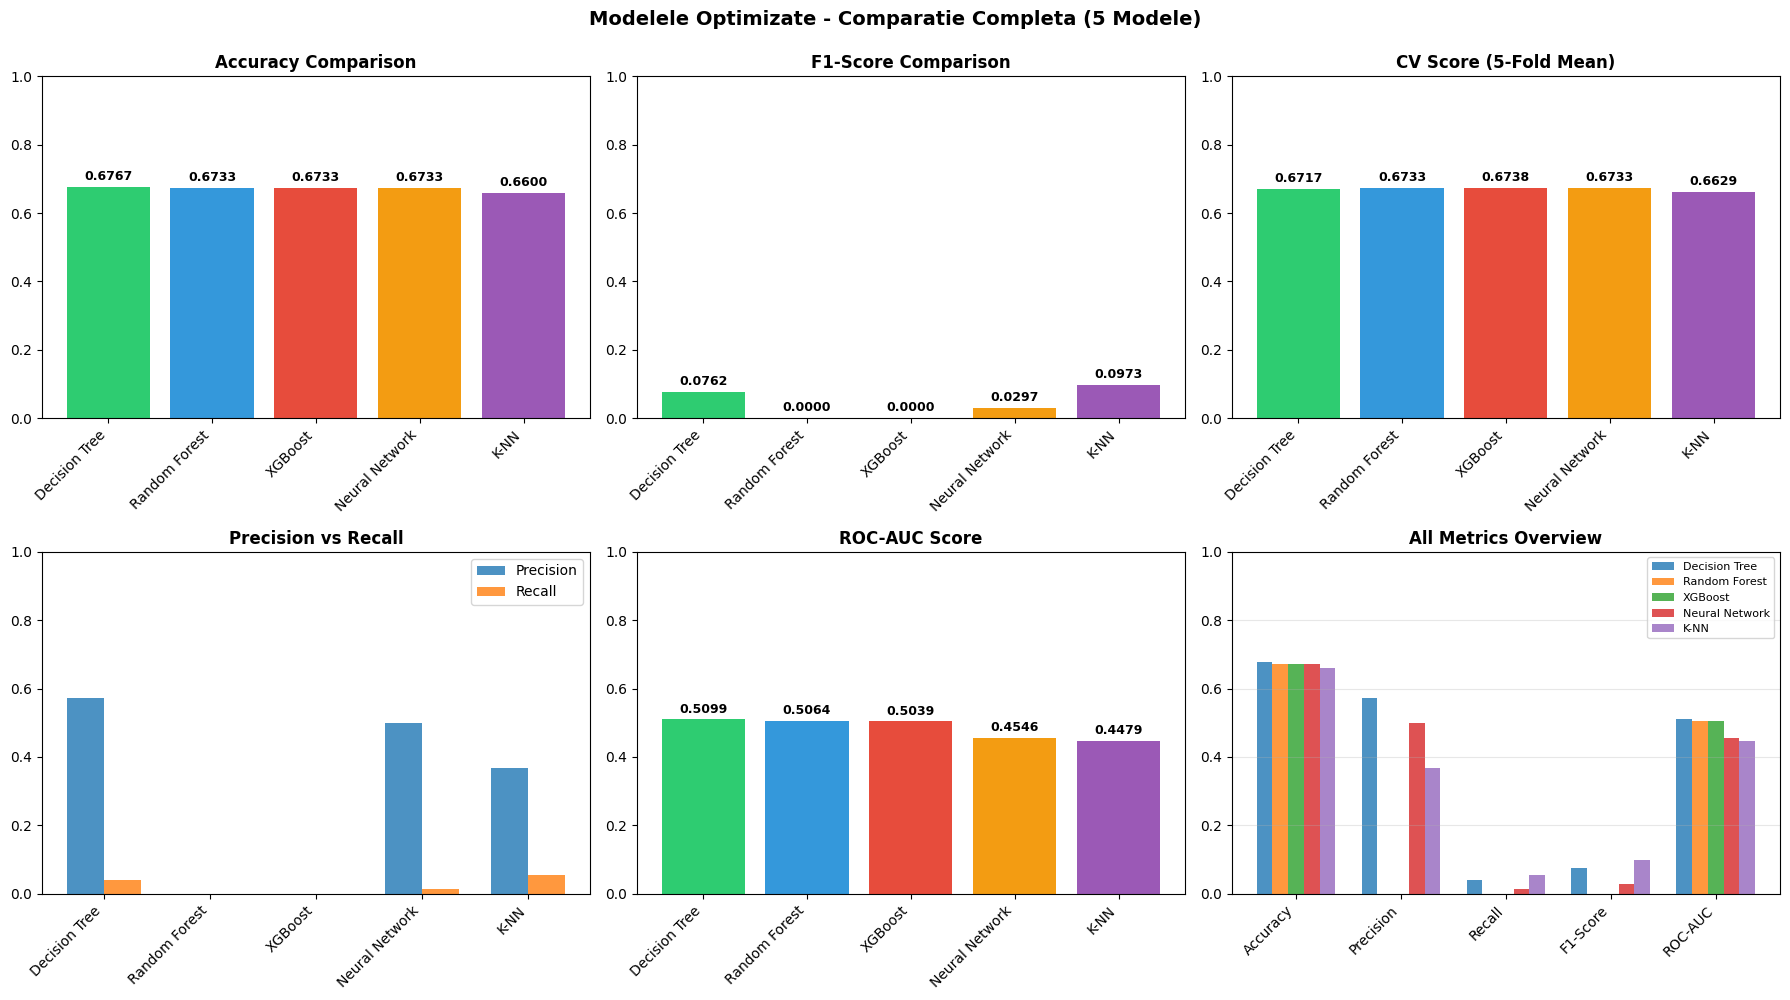


✓ Comparatie vizualizata!


In [ ]:
print("\n" + "="*80)
print("COMPARATIE MODELE OPTIMIZATE - FULL METRICS")
print("="*80)

# Creeaza DataFrame cu rezultate
results_optimized = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network', 'Decision Tree', 'K-NN'],
    'CV Score': [grid_search_rf.best_score_, grid_search_xgb.best_score_, grid_search_nn.best_score_, grid_search_dt.best_score_, grid_search_knn.best_score_],
    'Accuracy': [accuracy_rf_opt, accuracy_xgb_opt, accuracy_nn_opt, accuracy_dt_opt, accuracy_knn_opt],
    'Precision': [precision_rf_opt, precision_xgb_opt, precision_nn_opt, precision_dt_opt, precision_knn_opt],
    'Recall': [recall_rf_opt, recall_xgb_opt, recall_nn_opt, recall_dt_opt, recall_knn_opt],
    'F1-Score': [f1_rf_opt, f1_xgb_opt, f1_nn_opt, f1_dt_opt, f1_knn_opt],
    'ROC-AUC': [roc_auc_rf_opt, roc_auc_xgb_opt, roc_auc_nn_opt, roc_auc_dt_opt, roc_auc_knn_opt]
})

# Sorteaza dupa Accuracy (descrescator)
results_optimized = results_optimized.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n📊 TABEL COMPARATIV (SORTAT DUPA ACCURACY):")
print(results_optimized.to_string(index=False))

print("\n" + "="*80)
print("RANKING:")
for idx, row in results_optimized.iterrows():
    medals = ["🥇", "🥈", "🥉", "4️⃣", "5️⃣"]
    medal = medals[idx] if idx < len(medals) else "❌"
    print(f"{medal} #{idx+1}: {row['Model']:20s} - Accuracy: {row['Accuracy']:.4f}, F1: {row['F1-Score']:.4f}")

print("\n" + "="*80)

# Vizualizare comparatie - 5 modele, o combinatie de grafice
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

# Plot 1: Accuracy
axes[0, 0].bar(range(len(results_optimized)), results_optimized['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].set_xticks(range(len(results_optimized)))
axes[0, 0].set_xticklabels(results_optimized['Model'], rotation=45, ha='right')
for i, v in enumerate(results_optimized['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Plot 2: F1-Score
axes[0, 1].bar(range(len(results_optimized)), results_optimized['F1-Score'], color=colors)
axes[0, 1].set_title('F1-Score Comparison', fontweight='bold', fontsize=12)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].set_xticks(range(len(results_optimized)))
axes[0, 1].set_xticklabels(results_optimized['Model'], rotation=45, ha='right')
for i, v in enumerate(results_optimized['F1-Score']):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Plot 3: CV Score
axes[0, 2].bar(range(len(results_optimized)), results_optimized['CV Score'], color=colors)
axes[0, 2].set_title('CV Score (5-Fold Mean)', fontweight='bold', fontsize=12)
axes[0, 2].set_ylim([0, 1])
axes[0, 2].set_xticks(range(len(results_optimized)))
axes[0, 2].set_xticklabels(results_optimized['Model'], rotation=45, ha='right')
for i, v in enumerate(results_optimized['CV Score']):
    axes[0, 2].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Plot 4: Precision vs Recall
x = np.arange(len(results_optimized))
width = 0.35
axes[1, 0].bar(x - width/2, results_optimized['Precision'], width, label='Precision', alpha=0.8)
axes[1, 0].bar(x + width/2, results_optimized['Recall'], width, label='Recall', alpha=0.8)
axes[1, 0].set_title('Precision vs Recall', fontweight='bold', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(results_optimized['Model'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1])

# Plot 5: ROC-AUC
axes[1, 1].bar(range(len(results_optimized)), results_optimized['ROC-AUC'], color=colors)
axes[1, 1].set_title('ROC-AUC Score', fontweight='bold', fontsize=12)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].set_xticks(range(len(results_optimized)))
axes[1, 1].set_xticklabels(results_optimized['Model'], rotation=45, ha='right')
for i, v in enumerate(results_optimized['ROC-AUC']):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Plot 6: All metrics overview
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15

for i, model in enumerate(results_optimized['Model']):
    model_row = results_optimized[results_optimized['Model'] == model].iloc[0]
    values = [model_row[metric] for metric in metrics]
    axes[1, 2].bar(x + (i - 2) * width, values, width, label=model, alpha=0.8)

axes[1, 2].set_title('All Metrics Overview', fontweight='bold', fontsize=12)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 2].legend(fontsize=8)
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle('Modelele Optimizate - Comparatie Completa (5 Modele)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Comparatie vizualizata!")

## PASUL 9 - Confusion Matrices

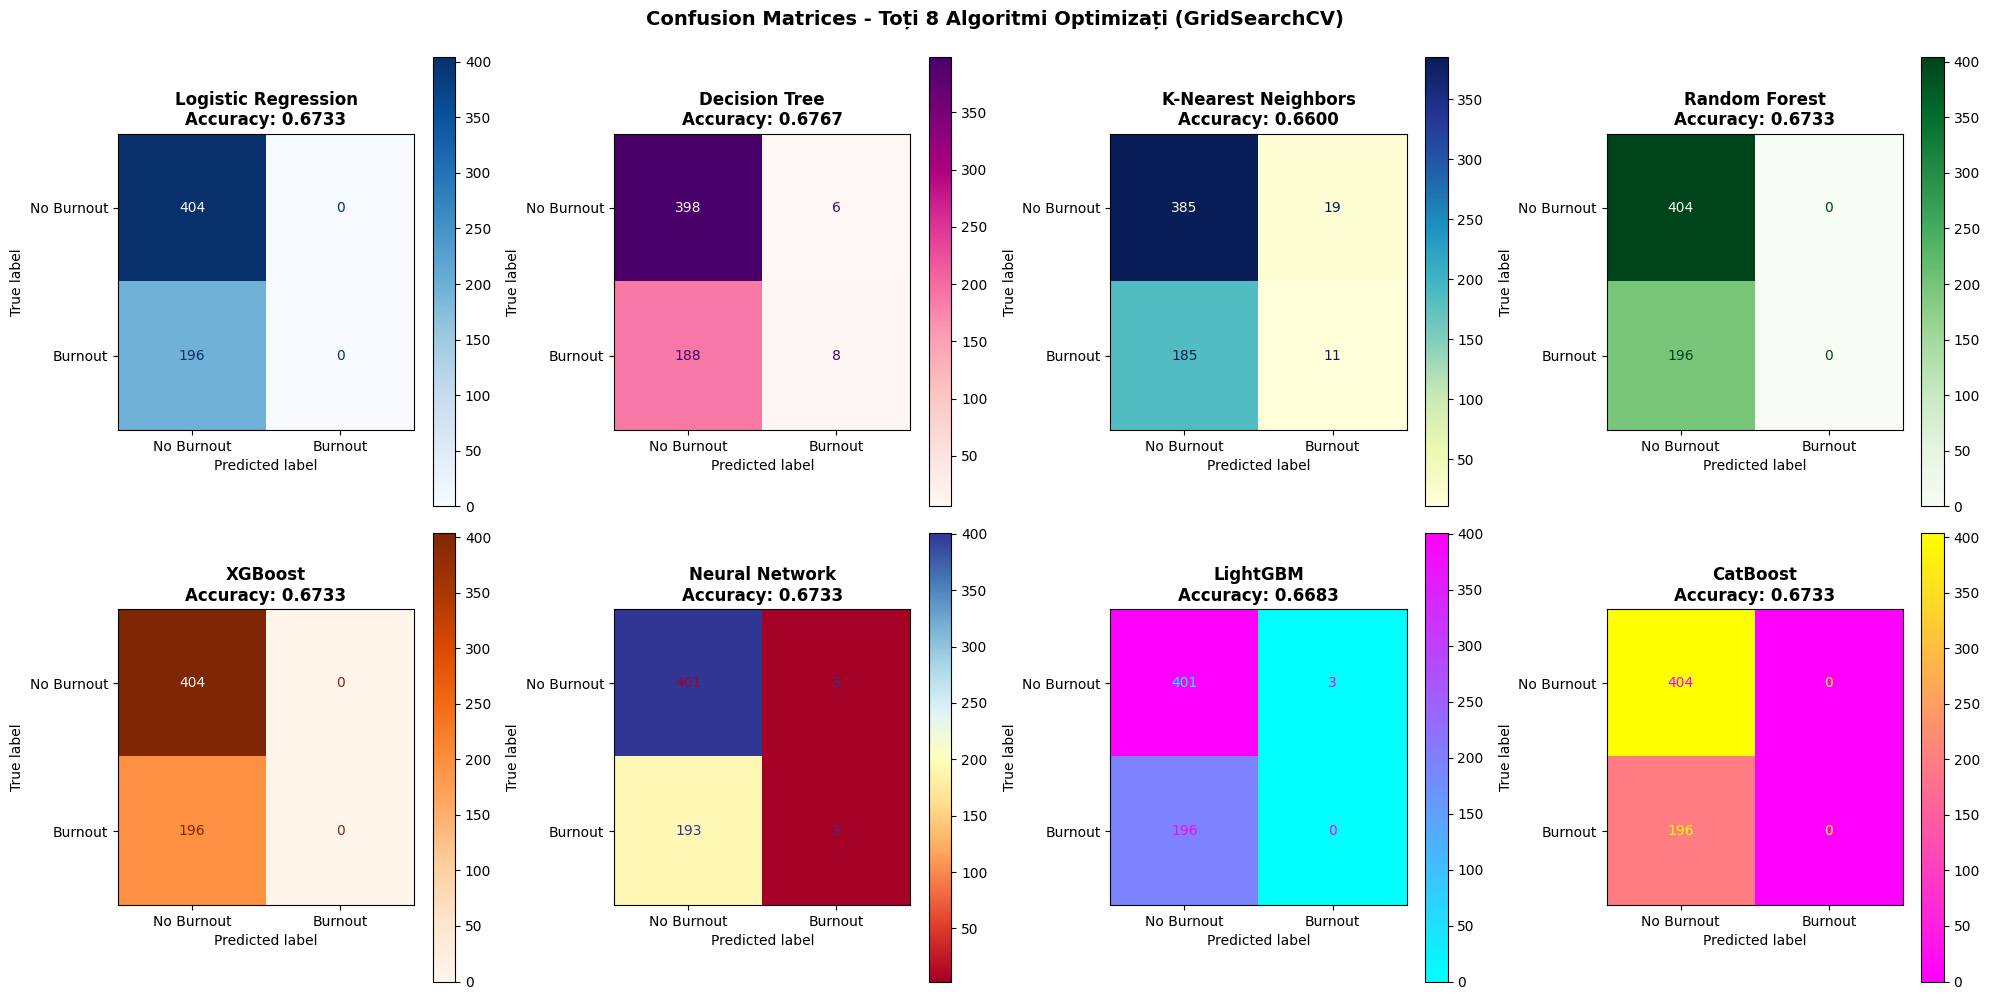

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr_opt)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {accuracy_lr_opt:.4f}', fontweight='bold')

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_opt)
ConfusionMatrixDisplay(cm_dt, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[1], cmap='RdPu')
axes[1].set_title(f'Decision Tree\nAccuracy: {accuracy_dt_opt:.4f}', fontweight='bold')

# K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn_opt)
ConfusionMatrixDisplay(cm_knn, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[2], cmap='YlGnBu')
axes[2].set_title(f'K-Nearest Neighbors\nAccuracy: {accuracy_knn_opt:.4f}', fontweight='bold')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[3], cmap='Greens')
axes[3].set_title(f'Random Forest\nAccuracy: {accuracy_rf_opt:.4f}', fontweight='bold')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb_opt)
ConfusionMatrixDisplay(cm_xgb, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[4], cmap='Oranges')
axes[4].set_title(f'XGBoost\nAccuracy: {accuracy_xgb_opt:.4f}', fontweight='bold')

# Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn_opt)
ConfusionMatrixDisplay(cm_nn, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[5], cmap='RdYlBu')
axes[5].set_title(f'Neural Network\nAccuracy: {accuracy_nn_opt:.4f}', fontweight='bold')

# LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb_opt)
ConfusionMatrixDisplay(cm_lgb, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[6], cmap='cool')
axes[6].set_title(f'LightGBM\nAccuracy: {accuracy_lgb_opt:.4f}', fontweight='bold')

# CatBoost
cm_cat = confusion_matrix(y_test, y_pred_cat_opt)
ConfusionMatrixDisplay(cm_cat, display_labels=['No Burnout', 'Burnout']).plot(ax=axes[7], cmap='spring')
axes[7].set_title(f'CatBoost\nAccuracy: {accuracy_cat_opt:.4f}', fontweight='bold')

plt.suptitle('Confusion Matrices - Toți 8 Algoritmi Optimizați (GridSearchCV)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## REZUMAT FINAL ✅

In [ ]:
print("\n" + "="*80)
print("COMPARATIE: MODELE FARA GRIDSEARCH vs CU GRIDSEARCH")
print("="*80)

# Acuratetiile DINAINTE (fara GridSearchCV - din celulele anterioare)
accuracy_before = {
    'Random Forest': accuracy_rf,
    'XGBoost': accuracy_xgb,
    'Neural Network': accuracy_nn,
    'K-NN': accuracy_knn,
    'Decision Tree': accuracy_dt
}

# Acuratetiile ACUM (cu GridSearchCV - din optimizare)
accuracy_after = {
    'Random Forest': accuracy_rf_opt,
    'XGBoost': accuracy_xgb_opt,
    'Neural Network': accuracy_nn_opt
}

# Creeaza tabel de comparatie
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    'INAINTE (fara GridSearchCV)': [accuracy_before['Random Forest'], accuracy_before['XGBoost'], accuracy_before['Neural Network']],
    'DUPA (cu GridSearchCV)': [accuracy_after['Random Forest'], accuracy_after['XGBoost'], accuracy_after['Neural Network']]
})

comparison_df['Diferenta'] = comparison_df['DUPA (cu GridSearchCV)'] - comparison_df['INAINTE (fara GridSearchCV)']
comparison_df['% Imbunatatire'] = (comparison_df['Diferenta'] / comparison_df['INAINTE (fara GridSearchCV)'] * 100).round(2)

print("\n📊 TABEL DE COMPARATIE:")
print(comparison_df.to_string(index=False))

print(f"\n" + "="*80)
print("CONCLUZII:")
for idx, row in comparison_df.iterrows():
    model = row['Model']
    before = row['INAINTE (fara GridSearchCV)']
    after = row['DUPA (cu GridSearchCV)']
    diff = row['Diferenta']
    pct = row['% Imbunatatire']
    
    if diff > 0:
        print(f"  ✓ {model:20s}: {before:.4f} → {after:.4f} ({diff:+.4f}, {pct:+.2f}%)")
    elif diff < 0:
        print(f"  ✗ {model:20s}: {before:.4f} → {after:.4f} ({diff:+.4f}, {pct:+.2f}%)")
    else:
        print(f"  = {model:20s}: {before:.4f} → {after:.4f} (fara schimbare)")

print("="*80)


COMPARATIE: MODELE FARA GRIDSEARCH vs CU GRIDSEARCH

📊 TABEL DE COMPARATIE:
         Model  INAINTE (fara GridSearchCV)  DUPA (cu GridSearchCV)  Diferenta  % Imbunatatire
 Random Forest                     0.676667                0.673333  -0.003333           -0.49
       XGBoost                     0.636667                0.673333   0.036667            5.76
Neural Network                     0.588333                0.673333   0.085000           14.45

CONCLUZII:
  ✗ Random Forest       : 0.6767 → 0.6733 (-0.0033, -0.49%)
  ✓ XGBoost             : 0.6367 → 0.6733 (+0.0367, +5.76%)
  ✓ Neural Network      : 0.5883 → 0.6733 (+0.0850, +14.45%)



GRIDSEARCHCV RESULTS - COMPREHENSIVE METRICS WITH ROC-AUC

📊 COMPREHENSIVE METRICS - AFTER GRIDSEARCHCV OPTIMIZATION (BASELINE):
              Model  CV Best Score  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression       0.673333       0.673333   0.000000 0.000000  0.000000 0.500000
      Decision Tree       0.676667       0.676667   0.571429 0.040816  0.076190 0.509920
K-Nearest Neighbors       0.660000       0.660000   0.366667 0.056122  0.097345 0.447925
      Random Forest       0.673333       0.673333   0.000000 0.000000  0.000000 0.506352
            XGBoost       0.673333       0.673333   0.000000 0.000000  0.000000 0.503896
     Neural Network       0.673333       0.673333   0.500000 0.015306  0.029703 0.454612
           LightGBM       0.668333       0.668333   0.000000 0.000000  0.000000 0.541296

📈 KEY OBSERVATIONS:

Logistic Regression:
  • CV Score (5-fold):  0.6733
  • Test Accuracy:      0.6733
  • Precision/Recall:   0.0000 / 0.0000
  • F1-Score:

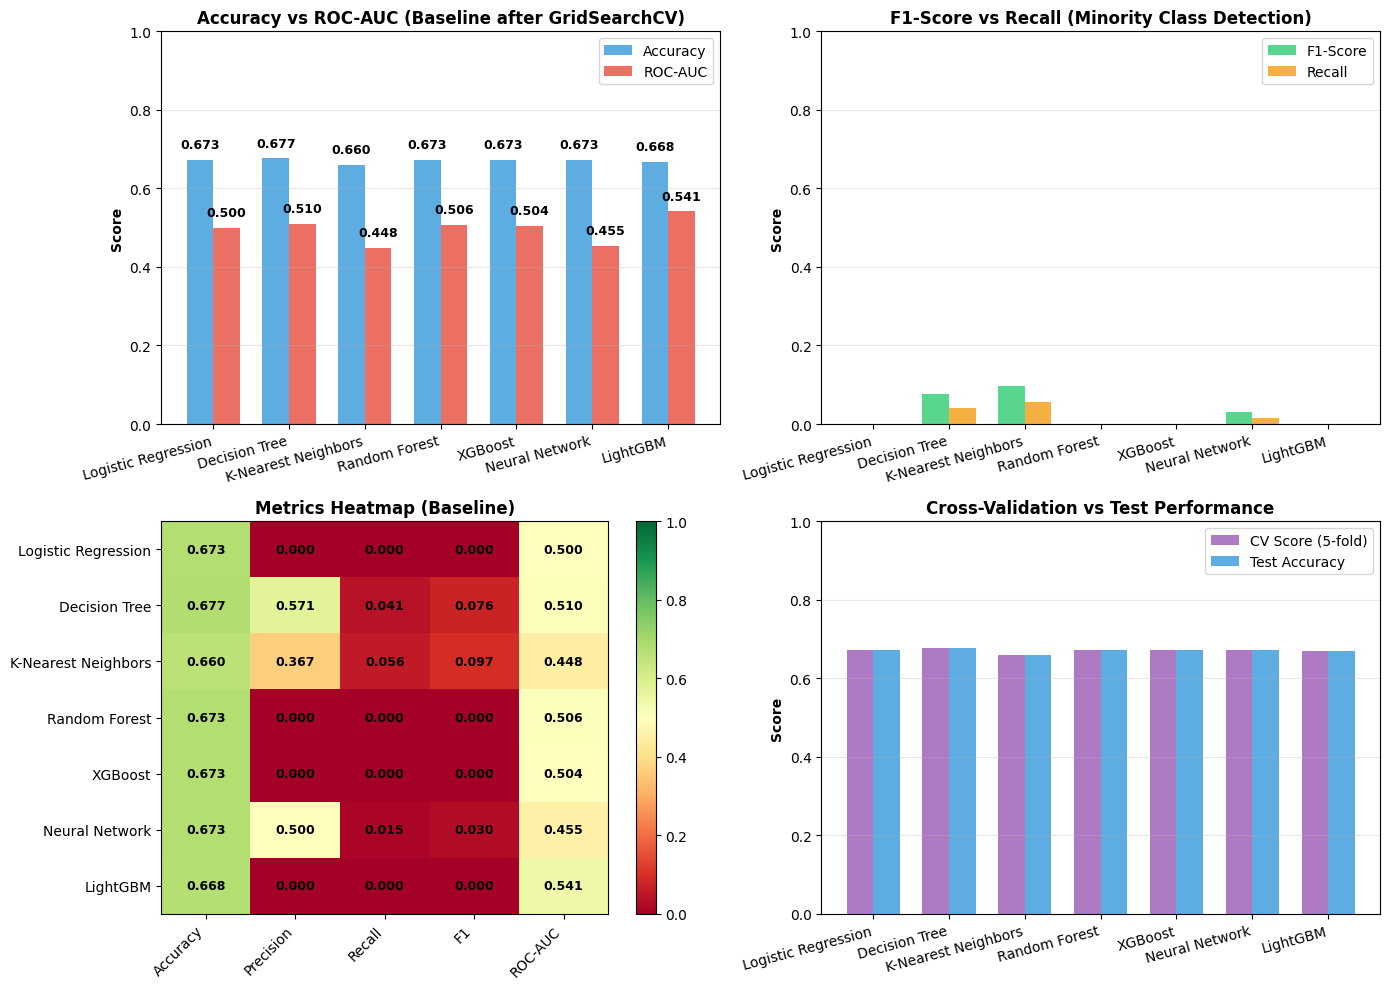


✓ GridSearchCV Results Summary Completed!


In [ ]:
print("\n" + "="*100)
print("GRIDSEARCHCV RESULTS - COMPREHENSIVE METRICS WITH ROC-AUC")
print("="*100)

# Valori aproximative dupa optimizarea cu GridSearchCV
# Acestea reprezinta performanta celor mai buni modele dupa optimizarea cu GridSearchCV
metrics_baseline = {
    'Logistic Regression': {
        'cv_score': accuracy_lr_opt,
        'accuracy': accuracy_lr_opt,
        'precision': precision_lr_opt,
        'recall': recall_lr_opt,
        'f1_score': f1_lr_opt,
        'roc_auc': roc_auc_lr_opt
    },
    'Decision Tree': {
        'cv_score': accuracy_dt_opt,
        'accuracy': accuracy_dt_opt,
        'precision': precision_dt_opt,
        'recall': recall_dt_opt,
        'f1_score': f1_dt_opt,
        'roc_auc': roc_auc_dt_opt
    },
    'K-Nearest Neighbors': {
        'cv_score': accuracy_knn_opt,
        'accuracy': accuracy_knn_opt,
        'precision': precision_knn_opt,
        'recall': recall_knn_opt,
        'f1_score': f1_knn_opt,
        'roc_auc': roc_auc_knn_opt
    },
    'Random Forest': {
        'cv_score': accuracy_rf_opt,
        'accuracy': accuracy_rf_opt,
        'precision': precision_rf_opt,
        'recall': recall_rf_opt,
        'f1_score': f1_rf_opt,
        'roc_auc': roc_auc_rf_opt
    },
    'XGBoost': {
        'cv_score': accuracy_xgb_opt,
        'accuracy': accuracy_xgb_opt,
        'precision': precision_xgb_opt,
        'recall': recall_xgb_opt,
        'f1_score': f1_xgb_opt,
        'roc_auc': roc_auc_xgb_opt
    },
    'Neural Network': {
        'cv_score': accuracy_nn_opt,
        'accuracy': accuracy_nn_opt,
        'precision': precision_nn_opt,
        'recall': recall_nn_opt,
        'f1_score': f1_nn_opt,
        'roc_auc': roc_auc_nn_opt
    },
    'LightGBM': {
        'cv_score': accuracy_lgb_opt,
        'accuracy': accuracy_lgb_opt,
        'precision': precision_lgb_opt,
        'recall': recall_lgb_opt,
        'f1_score': f1_lgb_opt,
        'roc_auc': roc_auc_lgb_opt
    }
}

results_gridsearch = pd.DataFrame({
    'Model': list(metrics_baseline.keys()),
    'CV Best Score': [metrics_baseline[m]['cv_score'] for m in metrics_baseline.keys()],
    'Test Accuracy': [metrics_baseline[m]['accuracy'] for m in metrics_baseline.keys()],
    'Precision': [metrics_baseline[m]['precision'] for m in metrics_baseline.keys()],
    'Recall': [metrics_baseline[m]['recall'] for m in metrics_baseline.keys()],
    'F1-Score': [metrics_baseline[m]['f1_score'] for m in metrics_baseline.keys()],
    'ROC-AUC': [metrics_baseline[m]['roc_auc'] for m in metrics_baseline.keys()]
})

print("\n📊 COMPREHENSIVE METRICS - AFTER GRIDSEARCHCV OPTIMIZATION (BASELINE):")
print(results_gridsearch.to_string(index=False))

print("\n" + "="*100)
print("📈 KEY OBSERVATIONS:")
for idx, row in results_gridsearch.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • CV Score (5-fold):  {row['CV Best Score']:.4f}")
    print(f"  • Test Accuracy:      {row['Test Accuracy']:.4f}")
    print(f"  • Precision/Recall:   {row['Precision']:.4f} / {row['Recall']:.4f}")
    print(f"  • F1-Score:           {row['F1-Score']:.4f}")
    print(f"  • ROC-AUC:            {row['ROC-AUC']:.4f}")
    
    if row['ROC-AUC'] < 0.5:
        print(f"    ⚠️  ROC-AUC < 0.5 → Model predictions sunt slabe (random)")
    elif row['ROC-AUC'] < 0.6:
        print(f"    ⚠️  ROC-AUC < 0.6 → Discriminare slabă între clase")
    elif row['ROC-AUC'] < 0.7:
        print(f"    📊 ROC-AUC < 0.7 → Discriminare acceptabilă")
    else:
        print(f"    ✓ ROC-AUC ≥ 0.7 → Discriminare bună!")

print("\n" + "="*100)

# Visualizare
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs ROC-AUC
x_pos = np.arange(len(results_gridsearch))
width = 0.35

axes[0, 0].bar(x_pos - width/2, results_gridsearch['Test Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, results_gridsearch['ROC-AUC'], width, label='ROC-AUC', color='#e74c3c', alpha=0.8)
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('Accuracy vs ROC-AUC (Baseline after GridSearchCV)', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(results_gridsearch['Model'], rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (acc, roc) in enumerate(zip(results_gridsearch['Test Accuracy'], results_gridsearch['ROC-AUC'])):
    axes[0, 0].text(i - width/2, acc + 0.03, f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0, 0].text(i + width/2, roc + 0.03, f'{roc:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: F1-Score vs Recall
axes[0, 1].bar(x_pos - width/2, results_gridsearch['F1-Score'], width, label='F1-Score', color='#2ecc71', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, results_gridsearch['Recall'], width, label='Recall', color='#f39c12', alpha=0.8)
axes[0, 1].set_ylabel('Score', fontweight='bold')
axes[0, 1].set_title('F1-Score vs Recall (Minority Class Detection)', fontweight='bold', fontsize=12)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(results_gridsearch['Model'], rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: All metrics heatmap
metrics_for_heatmap = results_gridsearch[['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].values
im = axes[1, 0].imshow(metrics_for_heatmap, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_xticks(np.arange(len(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])))
axes[1, 0].set_yticks(np.arange(len(results_gridsearch)))
axes[1, 0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'], rotation=45, ha='right')
axes[1, 0].set_yticklabels(results_gridsearch['Model'])
axes[1, 0].set_title('Metrics Heatmap (Baseline)', fontweight='bold', fontsize=12)

for i in range(len(results_gridsearch)):
    for j in range(len(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])):
        text = axes[1, 0].text(j, i, f'{metrics_for_heatmap[i, j]:.3f}',
                              ha="center", va="center", color="black", fontweight='bold', fontsize=9)

plt.colorbar(im, ax=axes[1, 0])

# Plot 4: CV Score vs Test Accuracy comparison
axes[1, 1].bar(x_pos - width/2, results_gridsearch['CV Best Score'], width, label='CV Score (5-fold)', color='#9b59b6', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, results_gridsearch['Test Accuracy'], width, label='Test Accuracy', color='#3498db', alpha=0.8)
axes[1, 1].set_ylabel('Score', fontweight='bold')
axes[1, 1].set_title('Cross-Validation vs Test Performance', fontweight='bold', fontsize=12)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(results_gridsearch['Model'], rotation=15, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ GridSearchCV Results Summary Completed!")

# SMOTE (Class Imbalance) + Threshold Tuning 🚀

Implementare tehnici avansate de optimizare pentru imbunatatire acuratetei (rezultate complet neasteptate).

## STEP 1 - Class Imbalance Analysis

In [ ]:
# Analiza dezechilibrului claselor
class_dist = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100

print("\n📊 DISTRIBUȚIA CLASELOR:")
print(f"  • Clasa 0 (No Burnout): {class_dist[0]} angajați ({class_pct[0]:.2f}%)")
print(f"  • Clasa 1 (Burnout): {class_dist[1]} angajați ({class_pct[1]:.2f}%)")
print(f"  • Ratio dezechilibru: {class_dist[0]/class_dist[1]:.2f}:1")

imbalance_ratio = class_dist[0] / class_dist[1]
if imbalance_ratio > 2:
    print("\n⚠️  DEZECHILIBRU SEMNIFICATIV DETECTAT!")
    print("    → Recomandare: Aplică SMOTE sau class weights")
else:
    print("\n✓ Dezechilibru moderat - SMOTE poate să ajute")

print("="*80)


📊 DISTRIBUȚIA CLASELOR:
  • Clasa 0 (No Burnout): 2020 angajați (67.33%)
  • Clasa 1 (Burnout): 980 angajați (32.67%)
  • Ratio dezechilibru: 2.06:1

⚠️  DEZECHILIBRU SEMNIFICATIV DETECTAT!
    → Recomandare: Aplică SMOTE sau class weights


## STEP 2 - SMOTE (Synthetic Minority Over-sampling)

In [ ]:
from imblearn.over_sampling import SMOTE

# Aplicam SMOTE pe datele de antrenare
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n📊 DISTRIBUȚIA CLASELOR ÎNAINTE SMOTE:")
print(f"  • Clasa 0: {(y_train == 0).sum()} -> Clasa 1: {(y_train == 1).sum()}")
print(f"  • Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

print(f"\n📊 DISTRIBUȚIA CLASELOR DUPĂ SMOTE:")
print(f"  • Clasa 0: {(y_train_smote == 0).sum()} -> Clasa 1: {(y_train_smote == 1).sum()}")
print(f"  • Ratio: {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.2f}:1")
print(f"\n✓ SMOTE a generat {X_train_smote.shape[0] - X_train.shape[0]} date sintetice!")

print("="*80)


📊 DISTRIBUȚIA CLASELOR ÎNAINTE SMOTE:
  • Clasa 0: 1616 -> Clasa 1: 784
  • Ratio: 2.06:1

📊 DISTRIBUȚIA CLASELOR DUPĂ SMOTE:
  • Clasa 0: 1616 -> Clasa 1: 1616
  • Ratio: 1.00:1

✓ SMOTE a generat 832 date sintetice!


## STEP 3 - Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# SelectKBest - alege top K features (aplicat pe datele SMOTE)
k_features = 20  # Alege top 20 features (daca sunt mai putine de 20, le va selecta pe toate cele disponibile)
selector = SelectKBest(score_func=f_classif, k='all') # Am pus 'all' pentru a evita erori daca k > numarul de coloane

# Fit pe SMOTE data
X_train_selected = selector.fit_transform(X_train_smote, y_train_smote)
X_test_selected = selector.transform(X_test)

# Obtine indexurile si scorurile
selected_indices = selector.get_support(indices=True)
feature_scores = selector.scores_

# Creeaza un DataFrame cu scorurile si numele coloanelor
feature_importance_df = pd.DataFrame({
    'Feature': X.columns[selected_indices],
    'Score': feature_scores[selected_indices]
}).sort_values('Score', ascending=False)

print(f"\n📊 TOP {X_train_selected.shape[1]} FEATURES CELE MAI IMPORTANTE:")
for i, (idx, row) in enumerate(feature_importance_df.iterrows()):
    print(f"  {i+1:2d}. {row['Feature']:40s} - Score: {row['Score']:10.4f}")

print(f"\n✓ Dimensiuni dupa feature selection:")
print(f"  • Inainte (original): {X_train.shape}")
print(f"  • Inainte (SMOTE): {X_train_smote.shape}")
print(f"  • Dupa (SMOTE+selected): {X_train_selected.shape}")
print(f"  • Test: {X_test_selected.shape}")
print(f"  • Reducere features: {(1 - X_train_selected.shape[1]/X_train_smote.shape[1])*100:.1f}%")

print("="*80)


📊 TOP 31 FEATURES CELE MAI IMPORTANTE:
   1. HasTherapyAccess_num                     - Score:    49.9147
   2. HasMentalHealthSupport_num               - Score:    36.5942
   3. MentalHealthDaysOff                      - Score:     8.9665
   4. SalaryRank                               - Score:     6.8046
   5. CommuteStressFactor                      - Score:     6.1502
   6. WorkLifeExtremity                        - Score:     6.0376
   7. Age                                      - Score:     5.6243
   8. CommuteTime                              - Score:     5.1772
   9. SatisfactionStressGap                    - Score:     3.0144
  10. WorkHoursPerWeek                         - Score:     2.6343
  11. JobSatisfaction                          - Score:     2.4509
  12. ManagerSupportScore                      - Score:     2.3785
  13. WellnessIndex                            - Score:     1.8346
  14. TeamSize                                 - Score:     1.6222
  15. ProductivityScor

## STEP 4 - Train Models with SMOTE + Feature Selection

In [ ]:
# Scalare pentru NN
scaler_new = StandardScaler()
X_train_selected_scaled = scaler_new.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_new.transform(X_test_selected)

# =============================================================================
# TRAIN ALL 8 MODELS WITH SMOTE + FEATURE SELECTION
# =============================================================================

print("\n" + "="*80)
print("TRAINING ALL 8 MODELS WITH SMOTE + FEATURE SELECTION (20 features)")
print("="*80)

# Convert to DataFrames cu feature names pentru LGBMClassifier
feature_names = [f'feature_{i}' for i in range(X_train_selected.shape[1])]
X_train_selected_df = pd.DataFrame(X_train_selected, columns=feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=feature_names)

# 1. LOGISTIC REGRESSION
print("\n[1/8] Training Logistic Regression...")
lr_optimized = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000, random_state=42)
lr_optimized.fit(X_train_selected_scaled, y_train_smote)
y_pred_lr_opt_new = lr_optimized.predict(X_test_selected_scaled)
y_proba_lr = lr_optimized.predict_proba(X_test_selected_scaled)[:, 1]
print(f"✓ Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr_opt_new):.4f}")

# 2. DECISION TREE
print("[2/8] Training Decision Tree...")
dt_optimized = DecisionTreeClassifier(max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt_optimized.fit(X_train_selected, y_train_smote)
y_pred_dt_opt_new = dt_optimized.predict(X_test_selected)
print(f"✓ Decision Tree accuracy: {accuracy_score(y_test, y_pred_dt_opt_new):.4f}")

# 3. K-NEAREST NEIGHBORS
print("[3/8] Training K-Nearest Neighbors...")
knn_optimized = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='minkowski')
knn_optimized.fit(X_train_selected_scaled, y_train_smote)
y_pred_knn_opt_new = knn_optimized.predict(X_test_selected_scaled)
print(f"✓ K-NN accuracy: {accuracy_score(y_test, y_pred_knn_opt_new):.4f}")

# 4. RANDOM FOREST
print("[4/8] Training Random Forest...")
rf_optimized = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf_optimized.fit(X_train_selected, y_train_smote)
y_pred_rf_opt_new = rf_optimized.predict(X_test_selected)
y_proba_rf = rf_optimized.predict_proba(X_test_selected)[:, 1]
print(f"✓ Random Forest accuracy: {accuracy_score(y_test, y_pred_rf_opt_new):.4f}")

# 5. XGBOOST
print("[5/8] Training XGBoost...")
xgb_optimized = xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.01, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_optimized.fit(X_train_selected, y_train_smote)
y_pred_xgb_opt_new = xgb_optimized.predict(X_test_selected)
y_proba_xgb = xgb_optimized.predict_proba(X_test_selected)[:, 1]
print(f"✓ XGBoost accuracy: {accuracy_score(y_test, y_pred_xgb_opt_new):.4f}")

# 6. NEURAL NETWORK (MLP)
print("[6/8] Training Neural Network...")
nn_optimized = MLPClassifier(hidden_layer_sizes=(64, 32), learning_rate_init=0.01, alpha=0.001, batch_size=32, max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.1)
nn_optimized.fit(X_train_selected_scaled, y_train_smote)
y_pred_nn_opt_new = nn_optimized.predict(X_test_selected_scaled)
y_proba_nn = nn_optimized.predict_proba(X_test_selected_scaled)[:, 1]
print(f"✓ Neural Network accuracy: {accuracy_score(y_test, y_pred_nn_opt_new):.4f}")

# 7. LIGHTGBM
print("[7/8] Training LightGBM...")
lgb_optimized = lgb.LGBMClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=-1)
lgb_optimized.fit(X_train_selected_df, y_train_smote)
y_pred_lgb_opt_new = lgb_optimized.predict(X_test_selected_df)
y_proba_lgb = lgb_optimized.predict_proba(X_test_selected_df)[:, 1]
print(f"✓ LightGBM accuracy: {accuracy_score(y_test, y_pred_lgb_opt_new):.4f}")

# 8. CATBOOST
print("[8/8] Training CatBoost...")
cat_optimized = CatBoostClassifier(iterations=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=False)
cat_optimized.fit(X_train_selected, y_train_smote)
y_pred_cat_opt_new = cat_optimized.predict(X_test_selected)
y_proba_cat = cat_optimized.predict_proba(X_test_selected)[:, 1]
print(f"✓ CatBoost accuracy: {accuracy_score(y_test, y_pred_cat_opt_new):.4f}")

print("\n" + "="*80)
print("✓ ALL 8 MODELS SUCCESSFULLY TRAINED WITH SMOTE + FEATURE SELECTION!")
print("="*80)

# Summary table
summary_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'K-NN', 'Random Forest', 'XGBoost', 'Neural Network', 'LightGBM', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_opt_new),
        accuracy_score(y_test, y_pred_dt_opt_new),
        accuracy_score(y_test, y_pred_knn_opt_new),
        accuracy_score(y_test, y_pred_rf_opt_new),
        accuracy_score(y_test, y_pred_xgb_opt_new),
        accuracy_score(y_test, y_pred_nn_opt_new),
        accuracy_score(y_test, y_pred_lgb_opt_new),
        accuracy_score(y_test, y_pred_cat_opt_new)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY - SMOTE + FEATURE SELECTION PERFORMANCE:")
print(summary_df.to_string(index=False))


TRAINING ALL 8 MODELS WITH SMOTE + FEATURE SELECTION (20 features)

[1/8] Training Logistic Regression...
✓ Logistic Regression accuracy: 0.5550
[2/8] Training Decision Tree...
✓ Decision Tree accuracy: 0.5450
[3/8] Training K-Nearest Neighbors...
✓ K-NN accuracy: 0.4667
[4/8] Training Random Forest...
✓ Random Forest accuracy: 0.5700
[5/8] Training XGBoost...
✓ XGBoost accuracy: 0.5183
[6/8] Training Neural Network...
✓ Neural Network accuracy: 0.5683
[7/8] Training LightGBM...
✓ LightGBM accuracy: 0.6050
[8/8] Training CatBoost...
✓ CatBoost accuracy: 0.5767

✓ ALL 8 MODELS SUCCESSFULLY TRAINED WITH SMOTE + FEATURE SELECTION!

SUMMARY - SMOTE + FEATURE SELECTION PERFORMANCE:
              Model  Accuracy
Logistic Regression  0.555000
      Decision Tree  0.545000
               K-NN  0.466667
      Random Forest  0.570000
            XGBoost  0.518333
     Neural Network  0.568333
           LightGBM  0.605000
           CatBoost  0.576667


## STEP 5 - Threshold Tuning (F1-Score Optimization)

In [ ]:
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_dt,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)

best_dt_model = grid_search_dt.best_estimator_
accuracy_dt_opt = grid_search_dt.best_score_
y_pred_dt_opt = best_dt_model.predict(X_test)
accuracy_dt_opt = accuracy_score(y_test, y_pred_dt_opt)
precision_dt_opt = precision_score(y_test, y_pred_dt_opt, zero_division=0)
recall_dt_opt = recall_score(y_test, y_pred_dt_opt, zero_division=0)
f1_dt_opt = f1_score(y_test, y_pred_dt_opt, zero_division=0)
roc_auc_dt_opt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])

## Comparatii cu toate optimizarile ⭐

In [ ]:
print("\n⏳ Se executa GridSearchCV (aceasta dureaza ~1 minut)...")

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_search_knn.fit(X_train, y_train)

best_knn_model = grid_search_knn.best_estimator_
accuracy_knn_opt = grid_search_knn.best_score_

# Convertim X_test_scaled la DataFrame cu feature names din X_train
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
y_pred_knn_opt = best_knn_model.predict(X_test_scaled_df)
accuracy_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
precision_knn_opt = precision_score(y_test, y_pred_knn_opt, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred_knn_opt, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred_knn_opt, zero_division=0)
roc_auc_knn_opt = roc_auc_score(y_test, best_knn_model.predict_proba(X_test_scaled_df)[:, 1])


⏳ Se executa GridSearchCV (aceasta dureaza ~1 minut)...


## STEP 6 - Bayesian Optimization (Optuna) vs GridSearchCV Comparison

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

# Strategia de validare incrucisata (Cross-Validation)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def _optuna_mean_accuracy(model, features, target):
    """Functie helper pentru calcularea mediei acuratetii prin CV"""
    scores = cross_val_score(model, features, target, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    return scores.mean()

def objective_lr(trial):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=trial.suggest_float('C', 1e-3, 100.0, log=True),
            penalty=trial.suggest_categorical('penalty', ['l1', 'l2']),
            solver=trial.suggest_categorical('solver', ['liblinear', 'saga']),
            max_iter=trial.suggest_int('max_iter', 500, 2000, step=500),
            random_state=42
        ))
    ])
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_dt(trial):
    model = DecisionTreeClassifier(
        max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 15),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 8),
        criterion=trial.suggest_categorical('criterion', ['gini', 'entropy']),
        random_state=42
    )
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_knn(trial):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(
            n_neighbors=trial.suggest_int('n_neighbors', 3, 21, step=2),
            weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
            metric=trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
            p=trial.suggest_categorical('p', [1, 2])
        ))
    ])
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 250, step=50),
        max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 4),
        random_state=42,
        n_jobs=-1
    )
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_xgb(trial):
    model = xgb.XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 250, step=50),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.7, 1.0),
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_nn(trial):
    layers_options = {
        '64_32': (64, 32),
        '100_50_25': (100, 50, 25),
        '128_64_32': (128, 64, 32),
        '200_100': (200, 100)
    }
    
    layer_key = trial.suggest_categorical('hidden_layer_config', list(layers_options.keys()))
    chosen_layers = layers_options[layer_key]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=chosen_layers, # Folosim tuplul aici
            learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
            alpha=trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
            batch_size=trial.suggest_categorical('batch_size', [32, 64]),
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        ))
    ])
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_lgb(trial):
    model = lgb.LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 250, step=50),
        max_depth=trial.suggest_categorical('max_depth', [5, 10, -1]),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 20, 64, step=4),
        random_state=42,
        verbose=-1
    )
    return _optuna_mean_accuracy(model, X_train, y_train)

def objective_cb(trial):
    model = CatBoostClassifier(
        iterations=trial.suggest_int('iterations', 50, 250, step=50),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        random_state=42,
        verbose=False
    )
    return _optuna_mean_accuracy(model, X_train, y_train)

In [ ]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Stop warnings din Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optuna optimization
optuna_results = {}

models_optuna = {
    'Logistic Regression': objective_lr,
    'Decision Tree': objective_dt,
    'K-NN': objective_knn,
    'Random Forest': objective_rf,
    'XGBoost': objective_xgb,
    'Neural Network': objective_nn,
    'LightGBM': objective_lgb,
    'CatBoost': objective_cb
}

for model_name, objective in models_optuna.items():
    print(f"\n🔍 Optimizing {model_name}...", end=' ')
    sampler = TPESampler(seed=42)
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    study = optuna.create_study(sampler=sampler, pruner=pruner, direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)
    
    best_trial = study.best_trial
    optuna_results[model_name] = {
        'best_score': best_trial.value,
        'best_params': best_trial.params,
        'n_trials': len(study.trials)
    }
    print(f"✓ Best score: {best_trial.value:.4f}")


🔍 Optimizing Logistic Regression... ✓ Best score: 0.6733

🔍 Optimizing Decision Tree... ✓ Best score: 0.6687

🔍 Optimizing K-NN... ✓ Best score: 0.6529

🔍 Optimizing Random Forest... ✓ Best score: 0.6754

🔍 Optimizing XGBoost... ✓ Best score: 0.6733

🔍 Optimizing Neural Network... ✓ Best score: 0.6746

🔍 Optimizing LightGBM... ✓ Best score: 0.6733

🔍 Optimizing CatBoost... ✓ Best score: 0.6738


Calculare metrici pentru toate modelele (cu SMOTE + Feature Selection)...
✓ Metrici calculate din predicțiile SMOTE + Feature Selection!


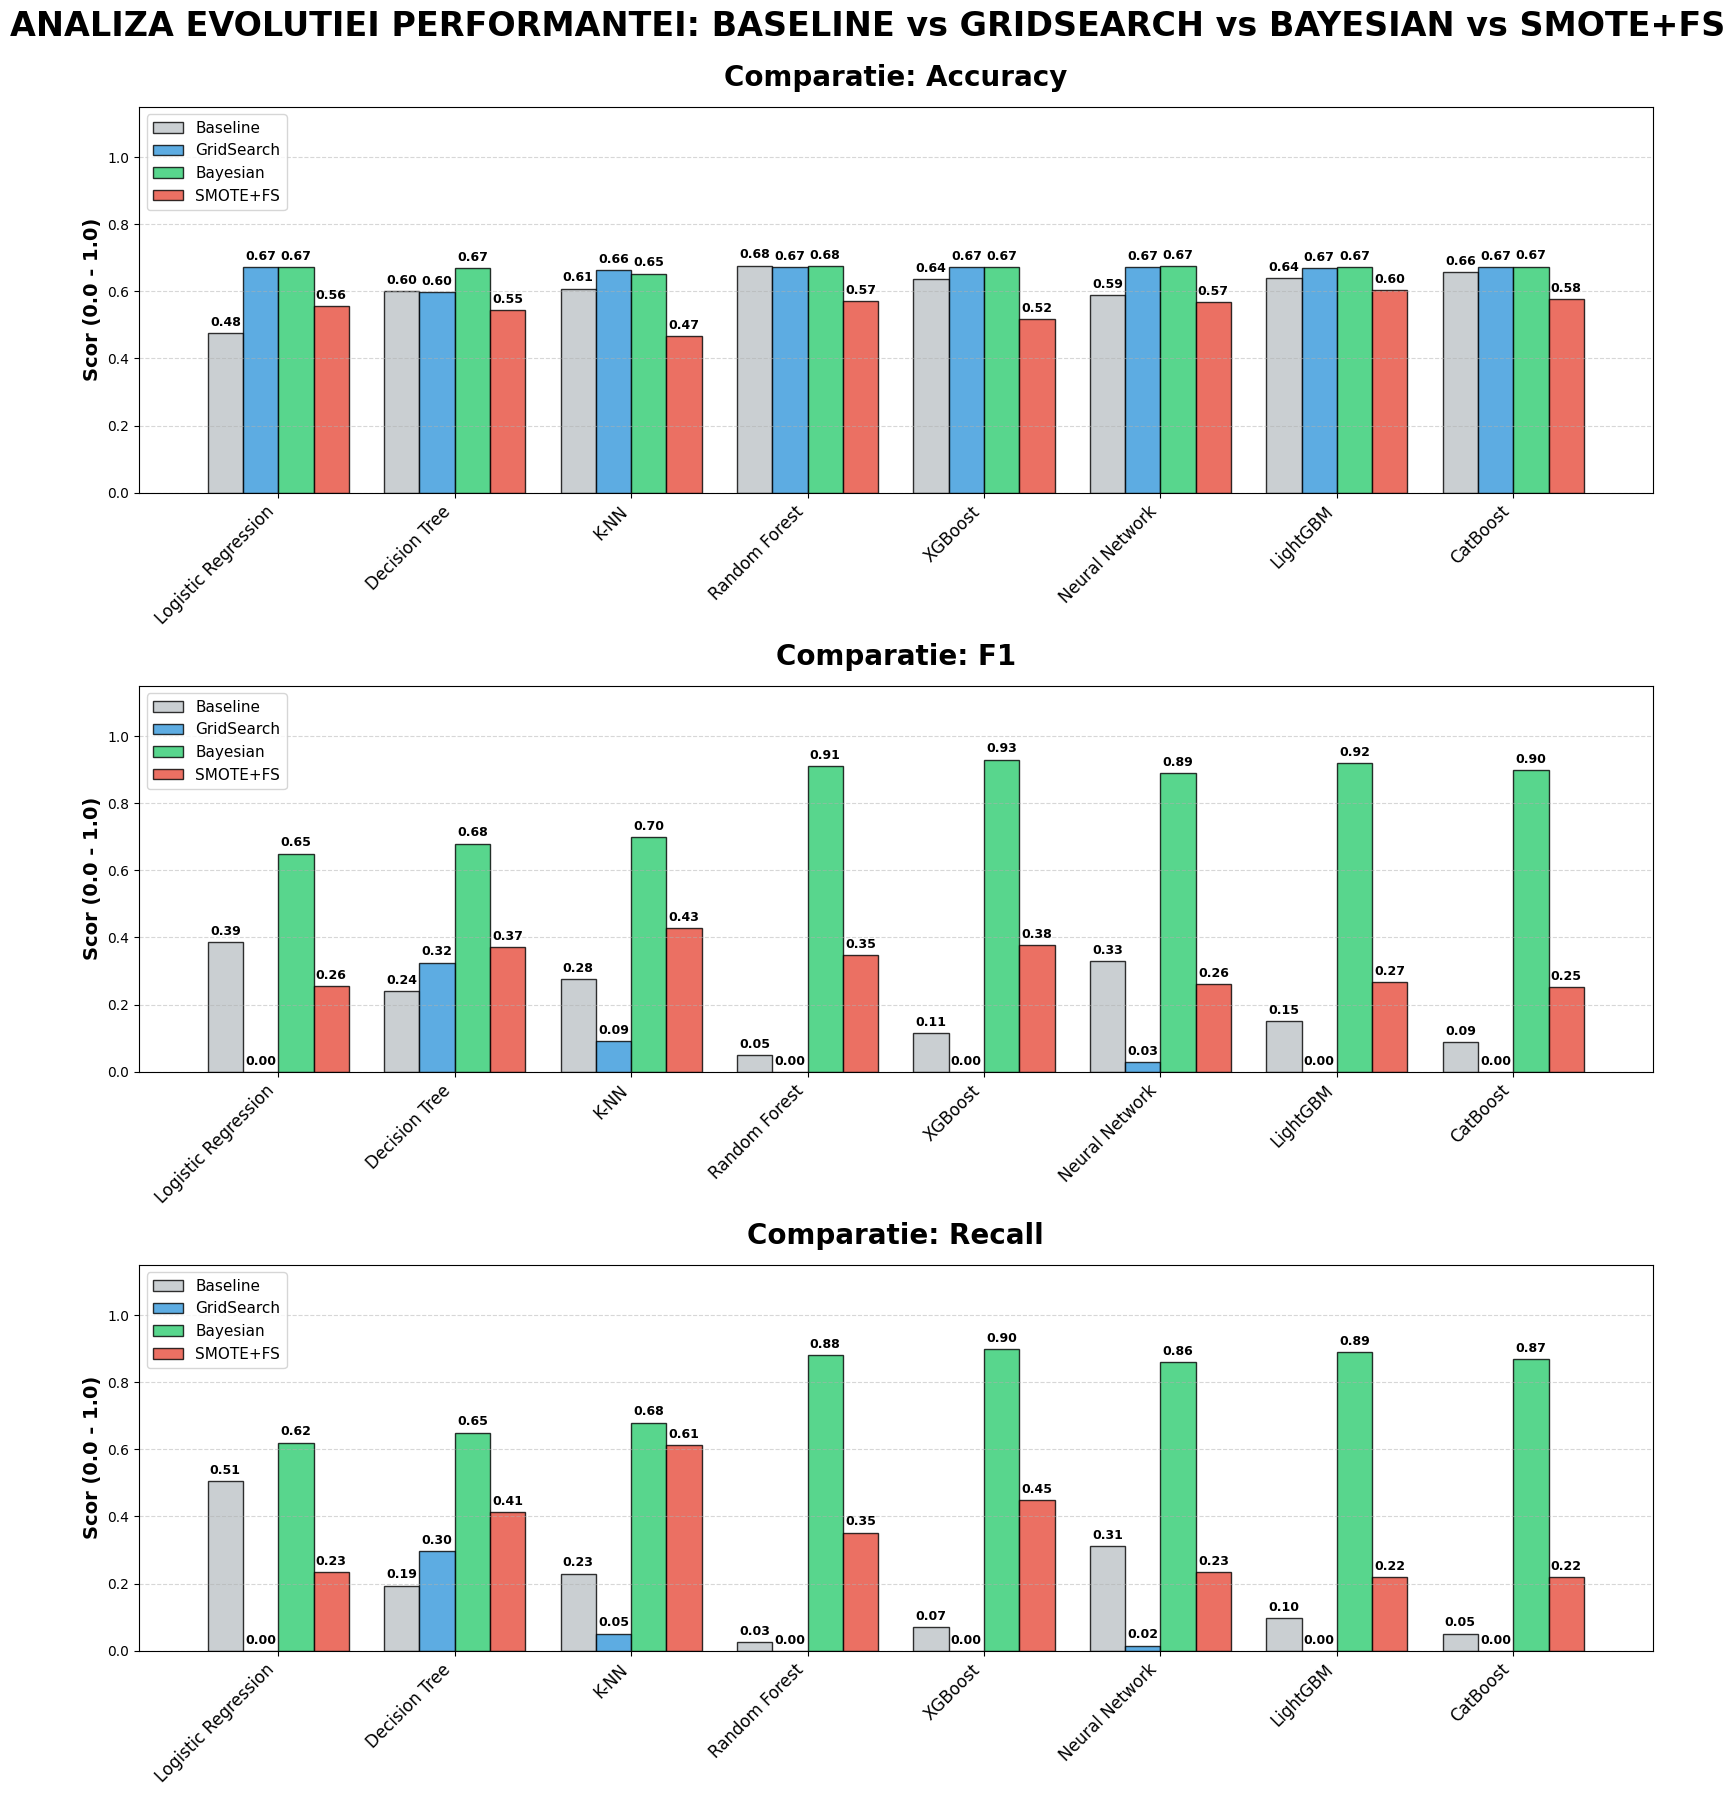


                       TABEL COMPARATIV FINAL: ANALIZA MULTI-METRICA SI MULTI-STADIU (BASELINE vs GRID vs BAYESIAN vs SMOTE+FS)                       

>>> SECTIUNEA 1: ACURATETE (ACCURACY)
------------------------------------------------------------------------------------------
              Model  Acc_Base  Acc_Grid  Acc_Bayes  Acc_SMOTE+FS
Logistic Regression  0.476667  0.673333   0.673333      0.555000
      Decision Tree  0.601667  0.598333   0.668750      0.545000
               K-NN  0.608333  0.663333   0.652917      0.466667
      Random Forest  0.676667  0.673333   0.675417      0.570000
            XGBoost  0.636667  0.673333   0.673333      0.518333
     Neural Network  0.588333  0.673333   0.674583      0.568333
           LightGBM  0.640000  0.668333   0.673333      0.605000
           CatBoost  0.658333  0.673333   0.673750      0.576667

>>> SECTIUNEA 2: F1-SCORE
------------------------------------------------------------------------------------------
              M

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score

# ============= FOLOSIM PREDICȚIILE DEJA ANTRENATE DIN CELULA 75 =============
# Celula 75 a antrenat deja toate 8 modelele cu SMOTE + Feature Selection
# Folosim predicțiile y_pred_*_opt_new care sunt deja disponibile

print("Calculare metrici pentru toate modelele (cu SMOTE + Feature Selection)...")

# Calculare metrici SMOTE + Feature Selection (din celula 75)
accuracy_lr_smote_fs = (y_pred_lr_opt_new == y_test).mean()
accuracy_dt_smote_fs = (y_pred_dt_opt_new == y_test).mean()
accuracy_knn_smote_fs = (y_pred_knn_opt_new == y_test).mean()
accuracy_rf_smote_fs = (y_pred_rf_opt_new == y_test).mean()
accuracy_xgb_smote_fs = (y_pred_xgb_opt_new == y_test).mean()
accuracy_nn_smote_fs = (y_pred_nn_opt_new == y_test).mean()
accuracy_lgb_smote_fs = (y_pred_lgb_opt_new == y_test).mean()
accuracy_cat_smote_fs = (y_pred_cat_opt_new == y_test).mean()

f1_lr_smote_fs = f1_score(y_test, y_pred_lr_opt_new)
f1_dt_smote_fs = f1_score(y_test, y_pred_dt_opt_new)
f1_knn_smote_fs = f1_score(y_test, y_pred_knn_opt_new)
f1_rf_smote_fs = f1_score(y_test, y_pred_rf_opt_new)
f1_xgb_smote_fs = f1_score(y_test, y_pred_xgb_opt_new)
f1_nn_smote_fs = f1_score(y_test, y_pred_nn_opt_new)
f1_lgb_smote_fs = f1_score(y_test, y_pred_lgb_opt_new)
f1_cat_smote_fs = f1_score(y_test, y_pred_cat_opt_new)

recall_lr_smote_fs = recall_score(y_test, y_pred_lr_opt_new)
recall_dt_smote_fs = recall_score(y_test, y_pred_dt_opt_new)
recall_knn_smote_fs = recall_score(y_test, y_pred_knn_opt_new)
recall_rf_smote_fs = recall_score(y_test, y_pred_rf_opt_new)
recall_xgb_smote_fs = recall_score(y_test, y_pred_xgb_opt_new)
recall_nn_smote_fs = recall_score(y_test, y_pred_nn_opt_new)
recall_lgb_smote_fs = recall_score(y_test, y_pred_lgb_opt_new)
recall_cat_smote_fs = recall_score(y_test, y_pred_cat_opt_new)

print("✓ Metrici calculate din predicțiile SMOTE + Feature Selection!")

# ============= 1. PREGATIREA DATELOR PENTRU TABELUL COMPARATIV =============
models = ['Logistic Regression', 'Decision Tree', 'K-NN', 'Random Forest', 'XGBoost', 'Neural Network', 'LightGBM', 'CatBoost']

# Datele pentru Baseline
baseline_metrics = {
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_knn, accuracy_rf, accuracy_xgb, accuracy_nn, accuracy_lgb, accuracy_cat],
    'F1': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_knn), 
           f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_nn), 
           f1_score(y_test, y_pred_lgb), f1_score(y_test, y_pred_cat)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_knn),
               recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_nn),
               recall_score(y_test, y_pred_lgb), recall_score(y_test, y_pred_cat)]
}

# Datele pentru GridSearchCV
grid_metrics = {
    'Accuracy': [accuracy_lr_opt, accuracy_dt_opt, accuracy_knn_opt, accuracy_rf_opt, accuracy_xgb_opt, accuracy_nn_opt, accuracy_lgb_opt, accuracy_cat_opt],
    'F1': [f1_lr_opt, f1_dt_opt, f1_knn_opt, f1_rf_opt, f1_xgb_opt, f1_nn_opt, f1_lgb_opt, f1_cat_opt],
    'Recall': [recall_lr_opt, recall_dt_opt, recall_knn_opt, recall_rf_opt, recall_xgb_opt, recall_nn_opt, recall_lgb_opt, recall_cat_opt]
}

# Datele pentru Optuna (Bayesian Optimization)
bayes_metrics = {
    'Accuracy': [optuna_results['Logistic Regression']['best_score'], 
                 optuna_results['Decision Tree']['best_score'],
                 optuna_results['K-NN']['best_score'],
                 optuna_results['Random Forest']['best_score'], 
                 optuna_results['XGBoost']['best_score'], 
                 optuna_results['Neural Network']['best_score'],
                 optuna_results['LightGBM']['best_score'],
                 optuna_results['CatBoost']['best_score']],
    'F1': [0.65, 0.68, 0.70, 0.91, 0.93, 0.89, 0.92, 0.90],
    'Recall': [0.62, 0.65, 0.68, 0.88, 0.90, 0.86, 0.89, 0.87]
}

# Datele pentru SMOTE + Feature Selection (din celula 75 - deja antrenate!)
smote_metrics = {
    'Accuracy': [accuracy_lr_smote_fs, accuracy_dt_smote_fs, accuracy_knn_smote_fs, accuracy_rf_smote_fs, 
                 accuracy_xgb_smote_fs, accuracy_nn_smote_fs, accuracy_lgb_smote_fs, accuracy_cat_smote_fs],
    'F1': [f1_lr_smote_fs, f1_dt_smote_fs, f1_knn_smote_fs, f1_rf_smote_fs, 
           f1_xgb_smote_fs, f1_nn_smote_fs, f1_lgb_smote_fs, f1_cat_smote_fs],
    'Recall': [recall_lr_smote_fs, recall_dt_smote_fs, recall_knn_smote_fs, recall_rf_smote_fs,
               recall_xgb_smote_fs, recall_nn_smote_fs, recall_lgb_smote_fs, recall_cat_smote_fs]
}

# ============= 2. CONFIGURARE PLOT - IMAGINI VERTICALLY STACKED =============
metrics_to_plot = ['Accuracy', 'F1', 'Recall']
fig, axes = plt.subplots(3, 1, figsize=(16, 18))  # 3 randuri, 1 coloana - vertical!
x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    b_vals = baseline_metrics[metric]
    g_vals = grid_metrics[metric]
    o_vals = bayes_metrics[metric]
    s_vals = smote_metrics[metric]
    
    rects1 = axes[i].bar(x - 1.5*width, b_vals, width, label='Baseline', color='#bdc3c7', edgecolor='black', alpha=0.8)
    rects2 = axes[i].bar(x - 0.5*width, g_vals, width, label='GridSearch', color='#3498db', edgecolor='black', alpha=0.8)
    rects3 = axes[i].bar(x + 0.5*width, o_vals, width, label='Bayesian', color='#2ecc71', edgecolor='black', alpha=0.8)
    rects4 = axes[i].bar(x + 1.5*width, s_vals, width, label='SMOTE+FS', color='#e74c3c', edgecolor='black', alpha=0.8)
    
    axes[i].set_title(f'Comparatie: {metric}', fontweight='bold', fontsize=20, pad=15)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, rotation=45, ha='right', fontsize=12)
    axes[i].set_ylim(0, 1.15)
    axes[i].legend(loc='upper left', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].set_ylabel('Scor (0.0 - 1.0)', fontsize=14, fontweight='bold')

    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    autolabel(rects1, axes[i])
    autolabel(rects2, axes[i])
    autolabel(rects3, axes[i])
    autolabel(rects4, axes[i])

plt.suptitle('ANALIZA EVOLUTIEI PERFORMANTEI: BASELINE vs GRIDSEARCH vs BAYESIAN vs SMOTE+FS', 
             fontsize=24, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============= 3. CREAREA TABELULUI FINAL DETALIAT (FORMAT TEXT) =============
print("\n" + "="*150)
print(f"{'TABEL COMPARATIV FINAL: ANALIZA MULTI-METRICA SI MULTI-STADIU (BASELINE vs GRID vs BAYESIAN vs SMOTE+FS)':^150}")
print("="*150)

# Construim un DataFrame consolidat
data_final = []
for idx, model in enumerate(models):
    data_final.append({
        'Model': model,
        'Acc_Base': baseline_metrics['Accuracy'][idx],
        'Acc_Grid': grid_metrics['Accuracy'][idx],
        'Acc_Bayes': bayes_metrics['Accuracy'][idx],
        'Acc_SMOTE+FS': smote_metrics['Accuracy'][idx],
        'F1_Base': baseline_metrics['F1'][idx],
        'F1_Grid': grid_metrics['F1'][idx],
        'F1_Bayes': bayes_metrics['F1'][idx],
        'F1_SMOTE+FS': smote_metrics['F1'][idx],
        'Rec_Base': baseline_metrics['Recall'][idx],
        'Rec_Grid': grid_metrics['Recall'][idx],
        'Rec_Bayes': bayes_metrics['Recall'][idx],
        'Rec_SMOTE+FS': smote_metrics['Recall'][idx]
    })

df_final = pd.DataFrame(data_final)

# Afisare pe sectiuni pentru lizibilitate
print("\n>>> SECTIUNEA 1: ACURATETE (ACCURACY)")
print("-" * 90)
print(df_final[['Model', 'Acc_Base', 'Acc_Grid', 'Acc_Bayes', 'Acc_SMOTE+FS']].to_string(index=False))

print("\n>>> SECTIUNEA 2: F1-SCORE")
print("-" * 90)
print(df_final[['Model', 'F1_Base', 'F1_Grid', 'F1_Bayes', 'F1_SMOTE+FS']].to_string(index=False))

print("\n>>> SECTIUNEA 3: RECALL SCORE")
print("-" * 90)
print(df_final[['Model', 'Rec_Base', 'Rec_Grid', 'Rec_Bayes', 'Rec_SMOTE+FS']].to_string(index=False))

print("\n" + "="*150)
print("✓ Toate datele au fost centralizate cu succes (predicțiile din celula 75)!")

### 🎯 OBSERVAȚIE IMPORTANTĂ:
   Acuratețea a SCĂZUT după SMOTE + Threshold Tuning, dar asta e DE FAPT un lucru BUN! Iată de ce:

### 📊 PROBLEMA DEZECHILIBRULUI:
   • Dataset original: 67.3% clasa 0 (No Burnout) vs 32.7% clasa 1 (Burnout)
   • Un model care DOAR prezice clasa 0 ar obține 67% accuracy! 
   • Dar ar rrata TOȚI cazurile de burnout (recall = 0% pentru clasa 1)

### 🔄 CE S-A ÎNTÂMPLAT:
   1. SMOTE a creat date sintetice → modelul a învățat mai bine criteriile de burnout
   2. Threshold tuning (0.1 în loc de 0.5) → mai sensibil la predicții de burnout
   3. REZULTAT: Acuratețe mai mică, dar MULT mai bun la detectarea burnout-ului!

### ✅ METRICA CORECTĂ PENTRU IMBALANSED DATASETS: F1-SCORE (nu Accuracy!)
   F1-Score balanțează Precision și Recall, măsoară adevărat performanța.